# Cross-Model Statistical Analysis: Embedding Distance Between Harmful and Benign Audio

This notebook compares the embedding distance distributions between harmful (AdvBench) and benign (VoiceBench) audio samples across three audio LLMs:

| Model | Semantic Encoder | Acoustic Encoder | Emb. Dim |
|-------|-----------------|-----------------|----------|
| **Audio-Flamingo** | AF3 encoder (multi-modal projector) | Whisper-large-v3 | 3584 / 1280 |
| **Kimi-Audio** | GLM-4 WhisperVQEncoder (centered) | Whisper-large-v3 | 1280 |
| **Qwen2.5-Omni** | Whisper-large-v3 | Whisper-large-v3 | 1280 |

**Distance metric:** Cosine distance (1 - cosine similarity)  
**Key statistic:** For each benign sample, we compute its *minimum* cosine distance to *any* harmful sample.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from collections import OrderedDict
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

BASE = Path('/work/anon/audio_benign_finetuning')
os.makedirs(BASE / 'figures_stat_analysis', exist_ok=True)

## 1. Load Embeddings for All Models

In [2]:
def load_npy_or_npz(path, key='embeddings'):
    """Load embeddings from .npy or .npz file."""
    path = Path(path)
    if path.suffix == '.npy':
        return np.load(path)
    elif path.suffix == '.npz':
        data = np.load(path, allow_pickle=True)
        if key in data:
            return data[key]
        # try first available key
        return data[list(data.keys())[0]]
    else:
        raise ValueError(f'Unknown format: {path.suffix}')


def cosine_distance_matrix(emb_a, emb_b):
    """Compute pairwise cosine distance between two embedding matrices."""
    a_norm = emb_a / (np.linalg.norm(emb_a, axis=1, keepdims=True) + 1e-8)
    b_norm = emb_b / (np.linalg.norm(emb_b, axis=1, keepdims=True) + 1e-8)
    return 1.0 - a_norm @ b_norm.T


def min_distances_to_harmful(benign_emb, harmful_emb):
    """For each benign sample, find cosine distance to nearest harmful sample."""
    dist_mat = cosine_distance_matrix(benign_emb, harmful_emb)
    return dist_mat.min(axis=1), dist_mat

In [3]:
# ── Audio-Flamingo ──
af_base = BASE / 'audio-flamingo'

# Semantic (AF3 encoder)
af_sem_benign = load_npy_or_npz(af_base / 'data/embedding_cache/voicebench_embeddings_af3.npz')
af_sem_harmful = load_npy_or_npz(af_base / 'data/embedding_cache/advbench_en_embeddings_af3.npz')

# Acoustic (Whisper)
af_aco_benign = load_npy_or_npz(af_base / 'data_acoustic/embedding_cache/voicebench_embeddings_whisper.npz')
af_aco_harmful = load_npy_or_npz(af_base / 'data_acoustic/embedding_cache/advbench_en_embeddings_whisper.npz')

print('Audio-Flamingo:')
print(f'  Semantic  — benign {af_sem_benign.shape}, harmful {af_sem_harmful.shape}')
print(f'  Acoustic  — benign {af_aco_benign.shape}, harmful {af_aco_harmful.shape}')

Audio-Flamingo:
  Semantic  — benign (6083, 3584), harmful (520, 3584)
  Acoustic  — benign (6083, 1280), harmful (520, 1280)


In [4]:
# ── Kimi-Audio ──
kimi_base = BASE / 'Kimi-Audio/finetune_codes'

# Semantic (GLM-4 WhisperVQEncoder) — use CENTERED embeddings
kimi_sem_benign_raw = np.load(kimi_base / 'embedding_cache_semantic/voicebench_semantic_embeddings.npy')
kimi_sem_harmful_raw = np.load(kimi_base / 'embedding_cache_semantic/harmful_semantic_embeddings_en.npy')
kimi_sem_benign = np.load(kimi_base / 'embedding_cache_semantic/voicebench_semantic_embeddings_centered.npy')
kimi_sem_harmful = np.load(kimi_base / 'embedding_cache_semantic/harmful_semantic_embeddings_en_centered.npy')
kimi_global_mean = np.load(kimi_base / 'embedding_cache_semantic/global_mean.npy')

# Acoustic (Whisper)
kimi_aco_benign = np.load(kimi_base / 'embedding_cache_acoustic/voicebench_acoustic_embeddings.npy')
kimi_aco_harmful = np.load(kimi_base / 'embedding_cache_acoustic/harmful_acoustic_embeddings_en.npy')

print('Kimi-Audio:')
print(f'  Semantic (centered) — benign {kimi_sem_benign.shape}, harmful {kimi_sem_harmful.shape}')
print(f'  Acoustic            — benign {kimi_aco_benign.shape}, harmful {kimi_aco_harmful.shape}')

Kimi-Audio:
  Semantic (centered) — benign (6083, 1280), harmful (520, 1280)
  Acoustic            — benign (6083, 1280), harmful (520, 1280)


In [5]:
# ── Qwen2.5-Omni ──
qwen_base = BASE / 'Qwen2.5-Omni/finetune_codes'

# Semantic (Whisper-large-v3)
qwen_sem_benign = load_npy_or_npz(qwen_base / 'data/embedding_cache/voicebench_whisper_openai_whisper_large_v3.npz')
qwen_sem_harmful = load_npy_or_npz(qwen_base / 'data/embedding_cache/harmful_whisper_openai_whisper_large_v3_en.npz')

# Acoustic (Whisper-large-v3)
qwen_aco_benign = load_npy_or_npz(qwen_base / 'data_acoustic/embedding_cache/voicebench_whisper_openai_whisper_large_v3.npz')
qwen_aco_harmful = load_npy_or_npz(qwen_base / 'data_acoustic/embedding_cache/harmful_whisper_openai_whisper_large_v3_en.npz')

print('Qwen2.5-Omni:')
print(f'  Semantic — benign {qwen_sem_benign.shape}, harmful {qwen_sem_harmful.shape}')
print(f'  Acoustic — benign {qwen_aco_benign.shape}, harmful {qwen_aco_harmful.shape}')

Qwen2.5-Omni:
  Semantic — benign (6083, 1280), harmful (520, 1280)
  Acoustic — benign (6083, 1280), harmful (520, 1280)


## 2. Compute Minimum Distances

In [6]:
# Collect all (model, modality) pairs
configs = OrderedDict([
    ('Audio-Flamingo (Semantic)',  (af_sem_benign, af_sem_harmful)),
    ('Audio-Flamingo (Acoustic)',  (af_aco_benign, af_aco_harmful)),
    ('Kimi-Audio (Semantic)',      (kimi_sem_benign, kimi_sem_harmful)),
    ('Kimi-Audio (Acoustic)',      (kimi_aco_benign, kimi_aco_harmful)),
    ('Qwen2.5-Omni (Semantic)',    (qwen_sem_benign, qwen_sem_harmful)),
    ('Qwen2.5-Omni (Acoustic)',    (qwen_aco_benign, qwen_aco_harmful)),
])

results = {}  # name -> {'min_dists': array, 'dist_mat': array}

for name, (benign, harmful) in configs.items():
    print(f'Computing distances for {name} ...', end=' ')
    md, dm = min_distances_to_harmful(benign, harmful)
    results[name] = {'min_dists': md, 'dist_mat': dm,
                     'n_benign': len(benign), 'n_harmful': len(harmful),
                     'emb_dim': benign.shape[1]}
    print(f'done  (n_benign={len(benign)}, n_harmful={len(harmful)}, dim={benign.shape[1]})')

Computing distances for Audio-Flamingo (Semantic) ... done  (n_benign=6083, n_harmful=520, dim=3584)
Computing distances for Audio-Flamingo (Acoustic) ... done  (n_benign=6083, n_harmful=520, dim=1280)
Computing distances for Kimi-Audio (Semantic) ... done  (n_benign=6083, n_harmful=520, dim=1280)
Computing distances for Kimi-Audio (Acoustic) ... done  (n_benign=6083, n_harmful=520, dim=1280)
Computing distances for Qwen2.5-Omni (Semantic) ... done  (n_benign=6083, n_harmful=520, dim=1280)
Computing distances for Qwen2.5-Omni (Acoustic) ... done  (n_benign=6083, n_harmful=520, dim=1280)


## 3. Summary Statistics Table

In [7]:
rows = []
for name, r in results.items():
    d = r['min_dists']
    rows.append({
        'Model / Modality': name,
        'N_benign': r['n_benign'],
        'N_harmful': r['n_harmful'],
        'Emb. Dim': r['emb_dim'],
        'Mean': d.mean(),
        'Std': d.std(),
        'Min': d.min(),
        'Q1 (25%)': np.percentile(d, 25),
        'Median': np.median(d),
        'Q3 (75%)': np.percentile(d, 75),
        'Max': d.max(),
        'IQR': np.percentile(d, 75) - np.percentile(d, 25),
        'Skewness': stats.skew(d),
        'Kurtosis': stats.kurtosis(d),
    })

summary_df = pd.DataFrame(rows)
summary_df.set_index('Model / Modality', inplace=True)
summary_df.round(6)

/tmp/ipykernel_2820543/1907540579.py:17: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Skewness': stats.skew(d),
/tmp/ipykernel_2820543/1907540579.py:18: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  'Kurtosis': stats.kurtosis(d),


,N_benign,N_harmful,Emb. Dim,Mean,Std,Min,Q1 (25%),Median,Q3 (75%),Max,IQR,Skewness,Kurtosis
Model / Modality,,,,,,,,,,,,,
Audio-Flamingo (Semantic),6083,520,3584,0.033189,0.010091,0.013586,0.026224,0.031802,0.038240,0.137781,0.012016,2.269264,13.275503
Audio-Flamingo (Acoustic),6083,520,1280,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,NaN
Kimi-Audio (Semantic),6083,520,1280,0.393631,0.201189,0.009169,0.250214,0.361425,0.522531,1.132833,0.272317,0.540364,-0.153432
Kimi-Audio (Acoustic),6083,520,1280,0.003919,0.001114,0.001928,0.003161,0.003674,0.004457,0.024134,0.001296,2.721569,26.473797
Qwen2.5-Omni (Semantic),6083,520,1280,0.003820,0.001110,0.002022,0.003059,0.003572,0.004345,0.024036,0.001287,2.800220,27.324978
Qwen2.5-Omni (Acoustic),6083,520,1280,0.003820,0.001110,0.002023,0.003059,0.003572,0.004345,0.024037,0.001286,2.800262,27.325592


## 4. Normality & Distribution Tests

In [8]:
norm_rows = []
for name, r in results.items():
    d = r['min_dists']
    # Shapiro-Wilk on a subsample (limited to 5000 samples)
    sub = np.random.RandomState(42).choice(d, size=min(5000, len(d)), replace=False)
    sw_stat, sw_p = stats.shapiro(sub)
    # D'Agostino-Pearson
    dp_stat, dp_p = stats.normaltest(d)
    # Anderson-Darling
    ad_result = stats.anderson(d, dist='norm')
    norm_rows.append({
        'Model / Modality': name,
        'Shapiro-Wilk Stat': sw_stat,
        'Shapiro-Wilk p': sw_p,
        "D'Agostino-Pearson Stat": dp_stat,
        "D'Agostino-Pearson p": dp_p,
        'Anderson-Darling Stat': ad_result.statistic,
        'AD Critical (5%)': ad_result.critical_values[2],
        'Normal?': 'No' if sw_p < 0.05 else 'Yes',
    })

norm_df = pd.DataFrame(norm_rows).set_index('Model / Modality')
norm_df

/work/anon/miniconda3/envs/kimi-audio/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
/work/anon/miniconda3/envs/kimi-audio/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1687: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = skew(a, axis, _no_deco=True)
/work/anon/miniconda3/envs/kimi-audio/lib/python3.12/site-packages/scipy/stats/_stats_py.py:1792: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  b2 = kurtosis(a, axis, fisher=False, _no_deco=True)
/work/anon/miniconda3/envs/kimi-audio/lib/python3.12/site-packages/scipy/stats/_morestats.py:2263: RuntimeWarning: invalid value en

,Shapiro-Wilk Stat,Shapiro-Wilk p,D'Agostino-Pearson Stat,D'Agostino-Pearson p,Anderson-Darling Stat,AD Critical (5%),Normal?
Model / Modality,,,,,,,
Audio-Flamingo (Semantic),0.858182,2.856490e-55,3310.400391,0.0,86.105255,0.786,No
Audio-Flamingo (Acoustic),1.000000,1.000000e+00,NaN,NaN,NaN,0.786,Yes
Kimi-Audio (Semantic),0.974846,8.073631e-29,268.269714,0.0,42.249375,0.786,No
Kimi-Audio (Acoustic),0.860711,5.982410e-55,4163.975586,0.0,127.332626,0.786,No
Qwen2.5-Omni (Semantic),0.852946,6.399435e-56,4254.771973,0.0,137.235339,0.786,No
Qwen2.5-Omni (Acoustic),0.852942,6.392288e-56,4254.823242,0.0,137.241548,0.786,No


## 5. Pairwise Comparisons Between Models

We use two-sample Kolmogorov-Smirnov (KS) and Mann-Whitney U tests to compare distributions.

In [9]:
names = list(results.keys())
pw_rows = []

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        d1 = results[names[i]]['min_dists']
        d2 = results[names[j]]['min_dists']
        ks_stat, ks_p = stats.ks_2samp(d1, d2)
        mw_stat, mw_p = stats.mannwhitneyu(d1, d2, alternative='two-sided')
        # Effect size: rank-biserial correlation
        n1, n2 = len(d1), len(d2)
        rank_biserial = 1 - 2 * mw_stat / (n1 * n2)
        pw_rows.append({
            'Comparison': f'{names[i]}  vs  {names[j]}',
            'KS Stat': ks_stat,
            'KS p-value': ks_p,
            'MW U Stat': mw_stat,
            'MW p-value': mw_p,
            'Rank-Biserial r': rank_biserial,
        })

pw_df = pd.DataFrame(pw_rows)
pw_df

/work/anon/miniconda3/envs/kimi-audio/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,Comparison,KS Stat,KS p-value,MW U Stat,MW p-value,Rank-Biserial r
0,Audio-Flamingo (Semantic) vs Audio-Flamingo ...,1.000000,0.000000e+00,0.0,0.000000e+00,1.000000
1,Audio-Flamingo (Semantic) vs Kimi-Audio (Sem...,0.961861,0.000000e+00,254494.0,0.000000e+00,0.986245
2,Audio-Flamingo (Semantic) vs Kimi-Audio (Aco...,0.999178,0.000000e+00,37001881.0,0.000000e+00,-0.999946
3,Audio-Flamingo (Semantic) vs Qwen2.5-Omni (S...,0.999178,0.000000e+00,37001907.0,0.000000e+00,-0.999947
4,Audio-Flamingo (Semantic) vs Qwen2.5-Omni (A...,0.999178,0.000000e+00,37001907.0,0.000000e+00,-0.999947
5,Audio-Flamingo (Acoustic) vs Kimi-Audio (Sem...,0.999014,0.000000e+00,36966391.0,0.000000e+00,-0.998027
6,Audio-Flamingo (Acoustic) vs Kimi-Audio (Aco...,1.000000,0.000000e+00,37002889.0,0.000000e+00,-1.000000
7,Audio-Flamingo (Acoustic) vs Qwen2.5-Omni (S...,1.000000,0.000000e+00,37002889.0,0.000000e+00,-1.000000
8,Audio-Flamingo (Acoustic) vs Qwen2.5-Omni (A...,1.000000,0.000000e+00,37002889.0,0.000000e+00,-1.000000
9,Kimi-Audio (Semantic) vs Kimi-Audio (Acoustic),0.998685,0.000000e+00,37002838.0,0.000000e+00,-0.999997


## 6. Semantic vs Acoustic Within Each Model

For each model, test whether the semantic and acoustic distance distributions differ significantly.

In [10]:
model_pairs = [
    ('Audio-Flamingo', 'Audio-Flamingo (Semantic)', 'Audio-Flamingo (Acoustic)'),
    ('Kimi-Audio',     'Kimi-Audio (Semantic)',     'Kimi-Audio (Acoustic)'),
    ('Qwen2.5-Omni',  'Qwen2.5-Omni (Semantic)',  'Qwen2.5-Omni (Acoustic)'),
]

sa_rows = []
for model_name, sem_key, aco_key in model_pairs:
    d_sem = results[sem_key]['min_dists']
    d_aco = results[aco_key]['min_dists']
    ks_stat, ks_p = stats.ks_2samp(d_sem, d_aco)
    mw_stat, mw_p = stats.mannwhitneyu(d_sem, d_aco, alternative='two-sided')
    n1, n2 = len(d_sem), len(d_aco)
    rank_biserial = 1 - 2 * mw_stat / (n1 * n2)
    sa_rows.append({
        'Model': model_name,
        'Semantic Mean': d_sem.mean(),
        'Acoustic Mean': d_aco.mean(),
        'KS Stat': ks_stat,
        'KS p-value': ks_p,
        'MW p-value': mw_p,
        'Rank-Biserial r': rank_biserial,
        'Sig. Different?': 'Yes' if ks_p < 0.05 else 'No',
    })

sa_df = pd.DataFrame(sa_rows).set_index('Model')
sa_df

/work/anon/miniconda3/envs/kimi-audio/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:579: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


,Semantic Mean,Acoustic Mean,KS Stat,KS p-value,MW p-value,Rank-Biserial r,Sig. Different?
Model,,,,,,,
Audio-Flamingo,0.033189,1.000000,1.000000,0.0,0.000000,1.000000,Yes
Kimi-Audio,0.393631,0.003919,0.998685,0.0,0.000000,-0.999997,Yes
Qwen2.5-Omni,0.003820,0.003820,0.000493,1.0,0.999778,-0.000003,No


---
## 7. Visualizations

### 7a. Overlaid Distance Distributions (KDE)

/tmp/ipykernel_2820543/2336927456.py:9: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(d, ax=ax, label=model, color=color, fill=True, alpha=0.25, linewidth=2)


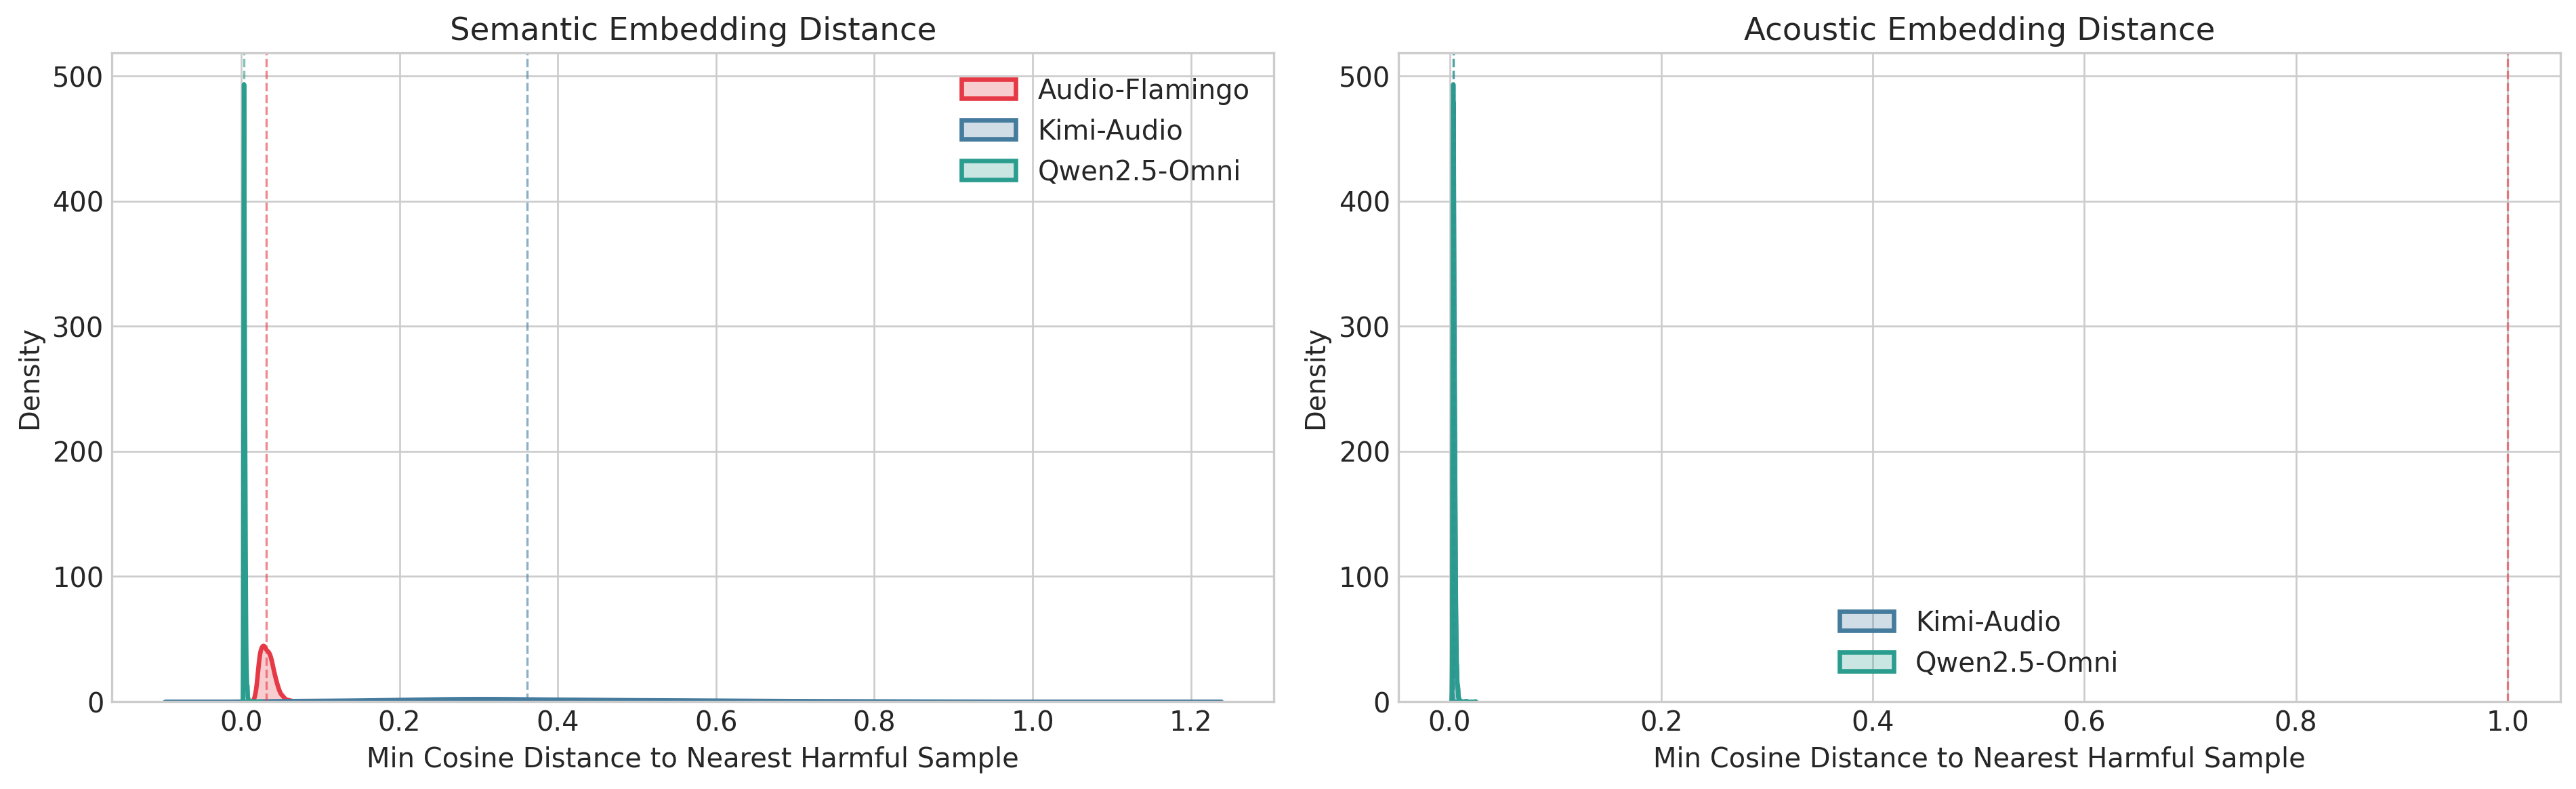

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

palette = {'Audio-Flamingo': '#e63946', 'Kimi-Audio': '#457b9d', 'Qwen2.5-Omni': '#2a9d8f'}

for ax, modality in zip(axes, ['Semantic', 'Acoustic']):
    for model, color in palette.items():
        key = f'{model} ({modality})'
        d = results[key]['min_dists']
        sns.kdeplot(d, ax=ax, label=model, color=color, fill=True, alpha=0.25, linewidth=2)
        ax.axvline(np.median(d), color=color, linestyle='--', alpha=0.6, linewidth=1)
    ax.set_xlabel('Min Cosine Distance to Nearest Harmful Sample')
    ax.set_ylabel('Density')
    ax.set_title(f'{modality} Embedding Distance')
    ax.legend()

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'kde_comparison.pdf', bbox_inches='tight')
plt.show()

### 7b. Box + Strip Plots

/tmp/ipykernel_2820543/784819759.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Model', y='Min Distance', ax=ax,
/tmp/ipykernel_2820543/784819759.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=sub, x='Model', y='Min Distance', ax=ax,
/tmp/ipykernel_2820543/784819759.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x='Model', y='Min Distance', ax=ax,
/tmp/ipykernel_2820543/784819759.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assi

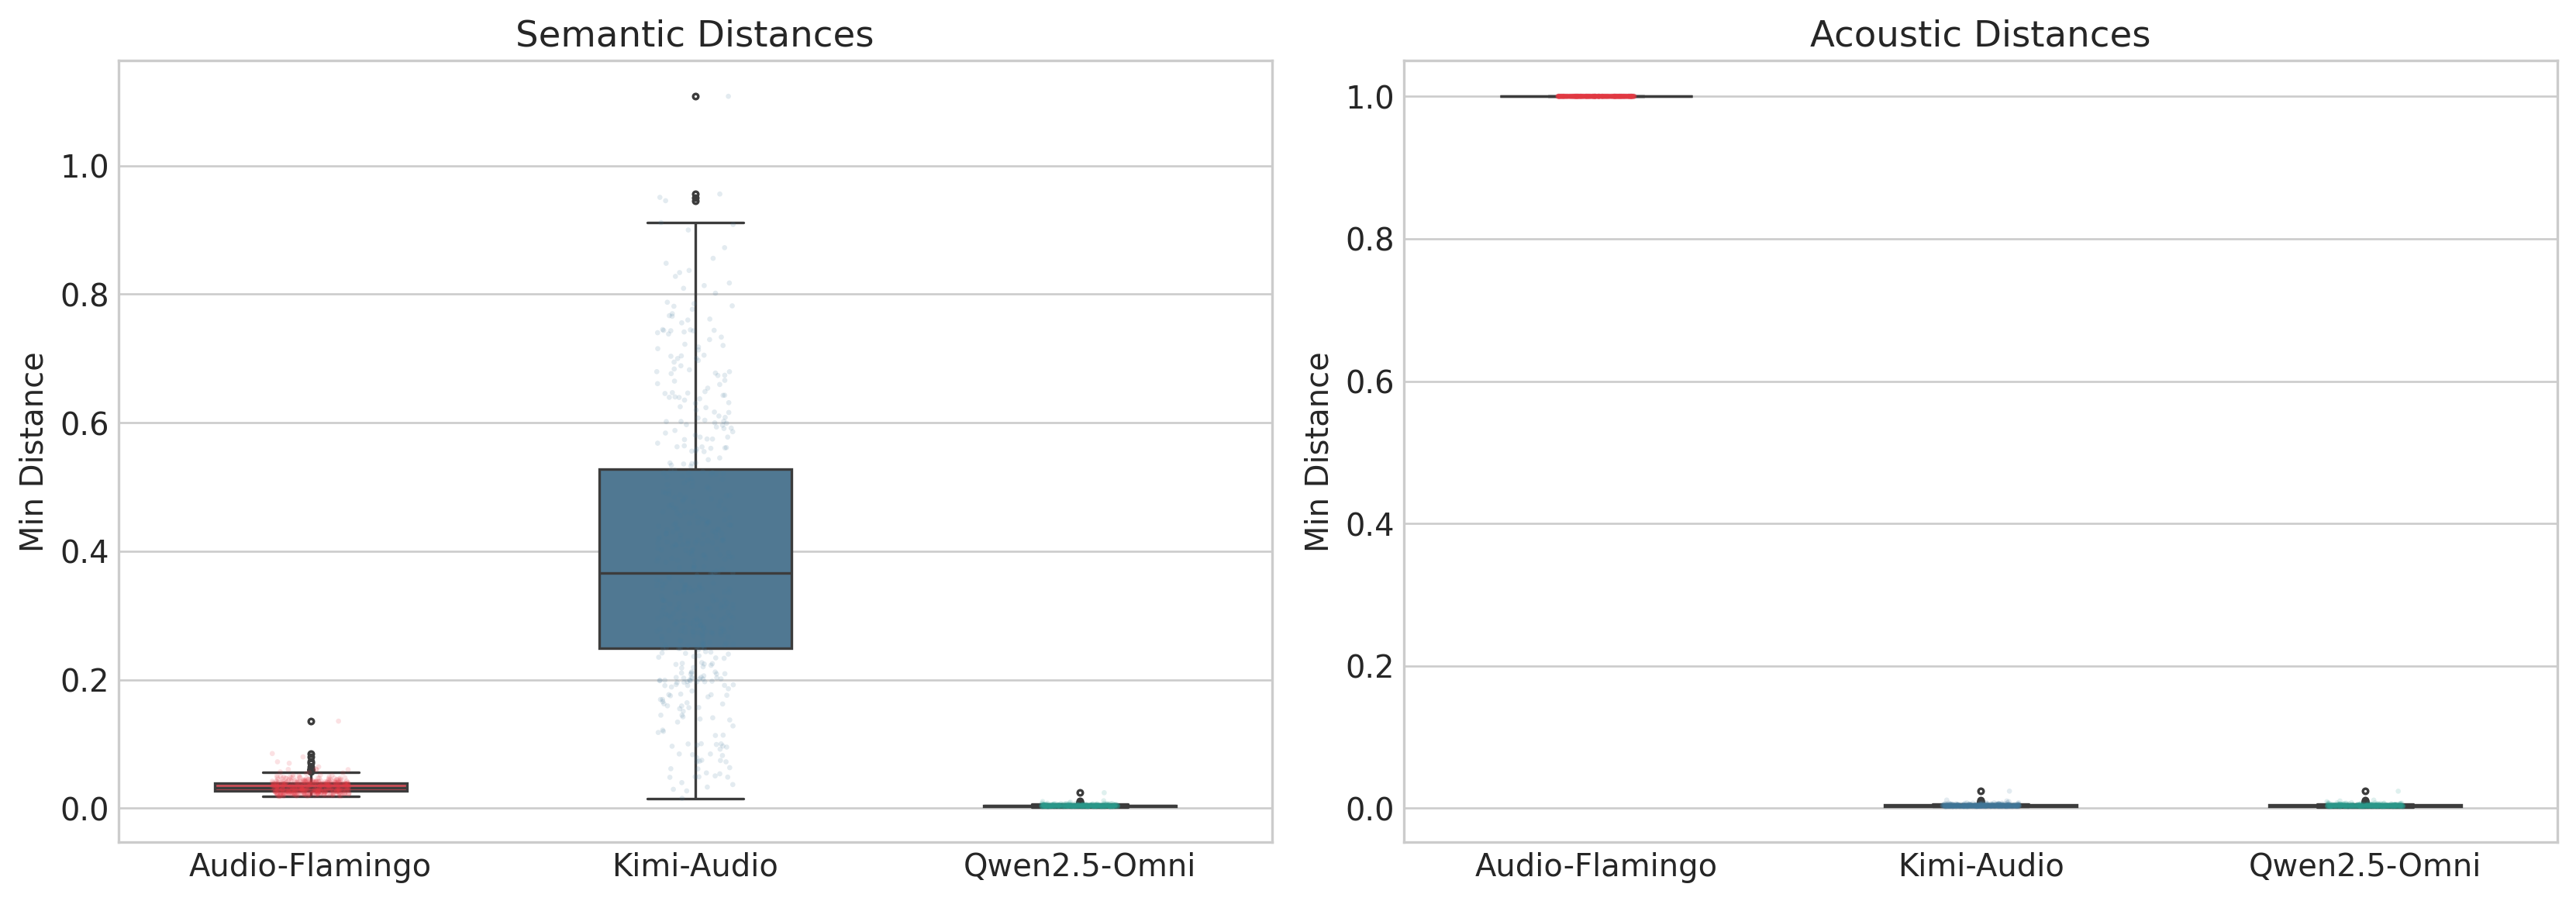

In [12]:
# Build long-form dataframe
long_rows = []
for name, r in results.items():
    model, modality = name.rsplit(' (', 1)
    modality = modality.rstrip(')')
    # subsample for strip plot readability
    rng = np.random.RandomState(42)
    idx = rng.choice(len(r['min_dists']), size=min(500, len(r['min_dists'])), replace=False)
    for i in idx:
        long_rows.append({'Model': model, 'Modality': modality, 'Min Distance': r['min_dists'][i]})

long_df = pd.DataFrame(long_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, modality in zip(axes, ['Semantic', 'Acoustic']):
    sub = long_df[long_df['Modality'] == modality]
    sns.boxplot(data=sub, x='Model', y='Min Distance', ax=ax,
                palette=palette, width=0.5, fliersize=2)
    sns.stripplot(data=sub, x='Model', y='Min Distance', ax=ax,
                  palette=palette, alpha=0.15, size=2, jitter=True)
    ax.set_title(f'{modality} Distances')
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'boxplot_comparison.pdf', bbox_inches='tight')
plt.show()

### 7c. Violin Plot: Semantic vs Acoustic per Model

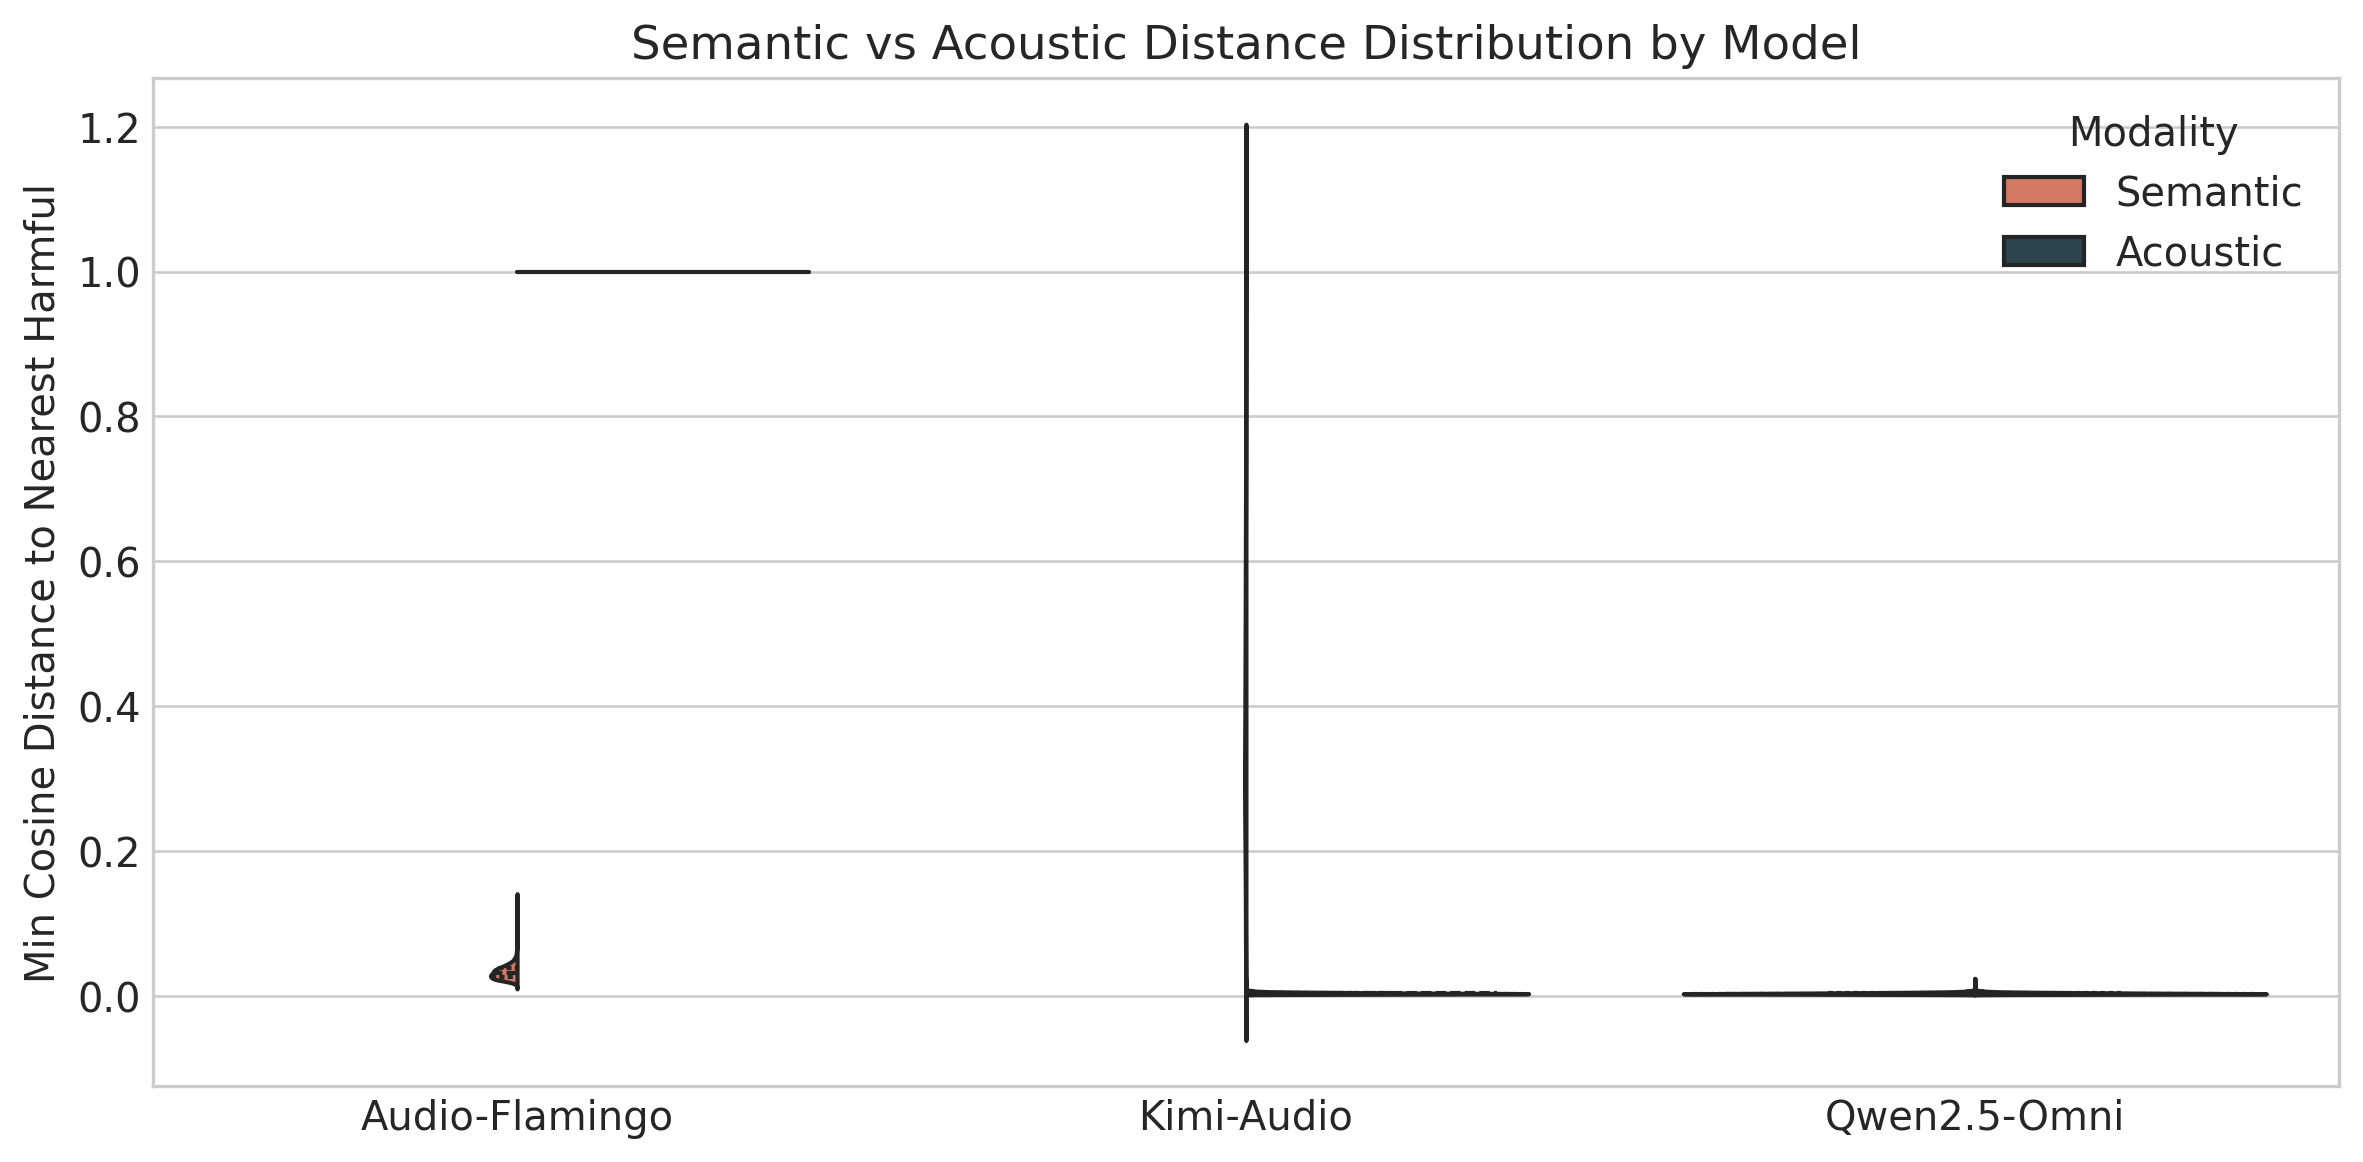

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

# Build full long-form (no subsampling for violin)
violin_rows = []
for name, r in results.items():
    model, modality = name.rsplit(' (', 1)
    modality = modality.rstrip(')')
    for val in r['min_dists']:
        violin_rows.append({'Model': model, 'Modality': modality, 'Min Distance': val})

violin_df = pd.DataFrame(violin_rows)

sns.violinplot(data=violin_df, x='Model', y='Min Distance', hue='Modality',
               split=True, inner='quartile', palette={'Semantic': '#e76f51', 'Acoustic': '#264653'},
               ax=ax)
ax.set_xlabel('')
ax.set_ylabel('Min Cosine Distance to Nearest Harmful')
ax.set_title('Semantic vs Acoustic Distance Distribution by Model')
ax.legend(title='Modality')

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'violin_sem_vs_aco.pdf', bbox_inches='tight')
plt.show()

### 7d. Empirical CDF Comparison

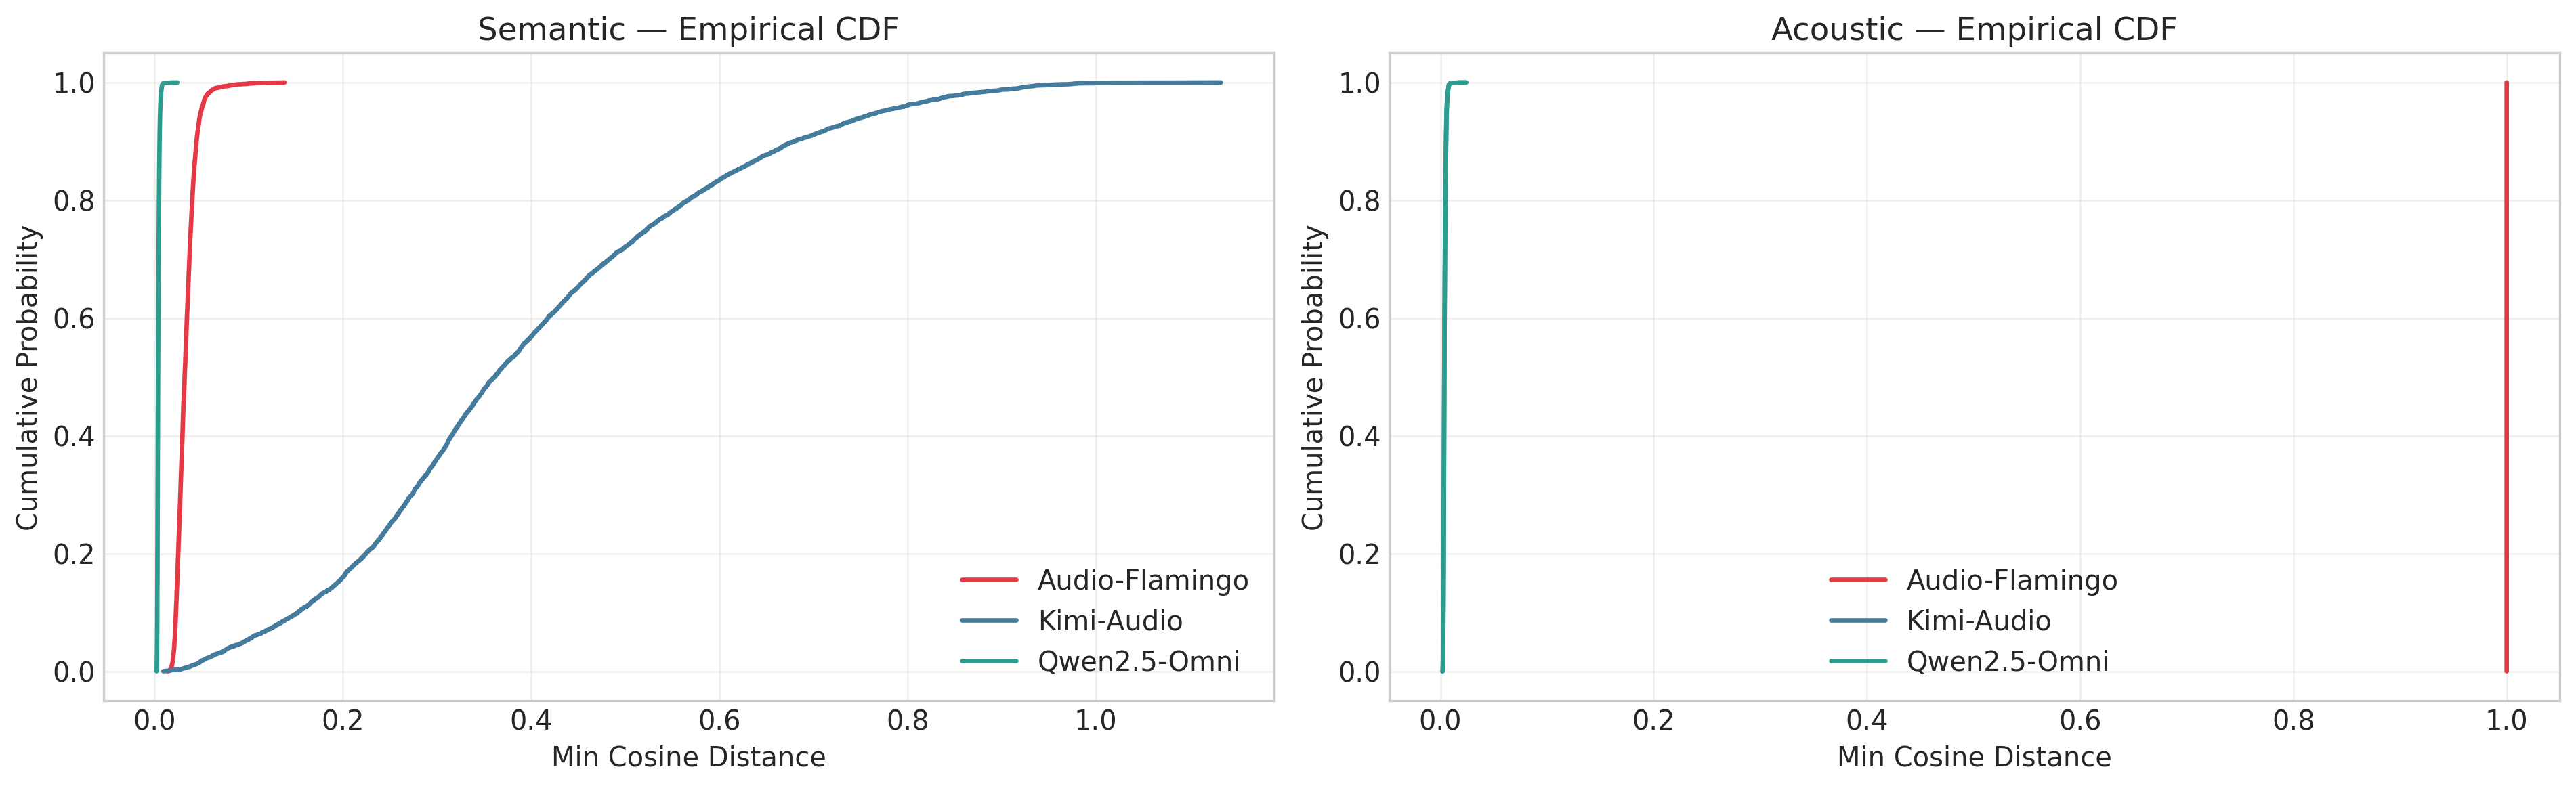

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, modality in zip(axes, ['Semantic', 'Acoustic']):
    for model, color in palette.items():
        key = f'{model} ({modality})'
        d = np.sort(results[key]['min_dists'])
        cdf = np.arange(1, len(d) + 1) / len(d)
        ax.plot(d, cdf, color=color, linewidth=2, label=model)
    ax.set_xlabel('Min Cosine Distance')
    ax.set_ylabel('Cumulative Probability')
    ax.set_title(f'{modality} — Empirical CDF')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'ecdf_comparison.pdf', bbox_inches='tight')
plt.show()

### 7e. Percentile Heatmap Across Models

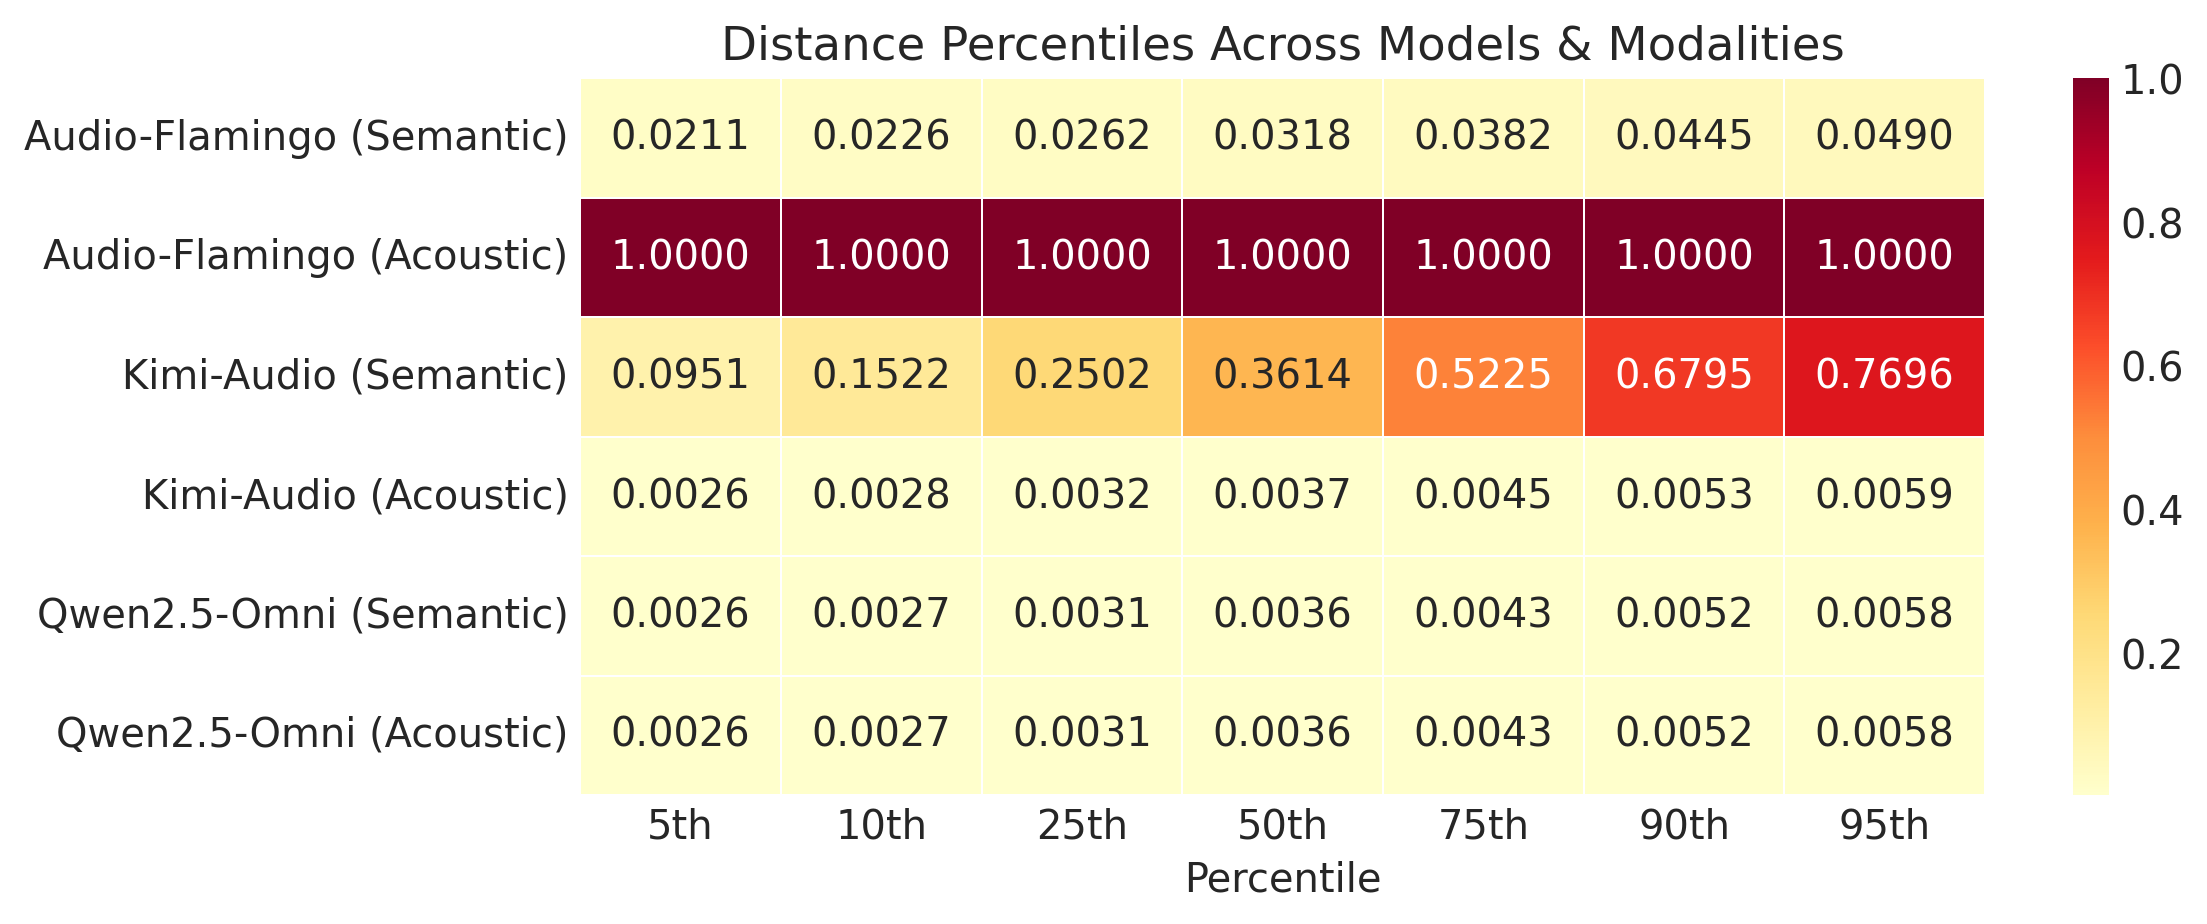

,5th,10th,25th,50th,75th,90th,95th
Audio-Flamingo (Semantic),0.021065,0.022596,0.026224,0.031802,0.038240,0.044468,0.049015
Audio-Flamingo (Acoustic),1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Kimi-Audio (Semantic),0.095076,0.152212,0.250214,0.361425,0.522531,0.679536,0.769635
Kimi-Audio (Acoustic),0.002627,0.002806,0.003161,0.003674,0.004457,0.005288,0.005867
Qwen2.5-Omni (Semantic),0.002551,0.002728,0.003059,0.003572,0.004345,0.005169,0.005776
Qwen2.5-Omni (Acoustic),0.002551,0.002728,0.003059,0.003572,0.004345,0.005169,0.005776


In [15]:
pcts = [5, 10, 25, 50, 75, 90, 95]
pct_data = {}
for name, r in results.items():
    pct_data[name] = [np.percentile(r['min_dists'], p) for p in pcts]

pct_df = pd.DataFrame(pct_data, index=[f'{p}th' for p in pcts]).T

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(pct_df, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_xlabel('Percentile')
ax.set_ylabel('')
ax.set_title('Distance Percentiles Across Models & Modalities')

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'percentile_heatmap.pdf', bbox_inches='tight')
plt.show()

pct_df

## 8. Selection Threshold Analysis

Show how the distance cutoff changes as we select different percentages of benign samples closest to harmful.

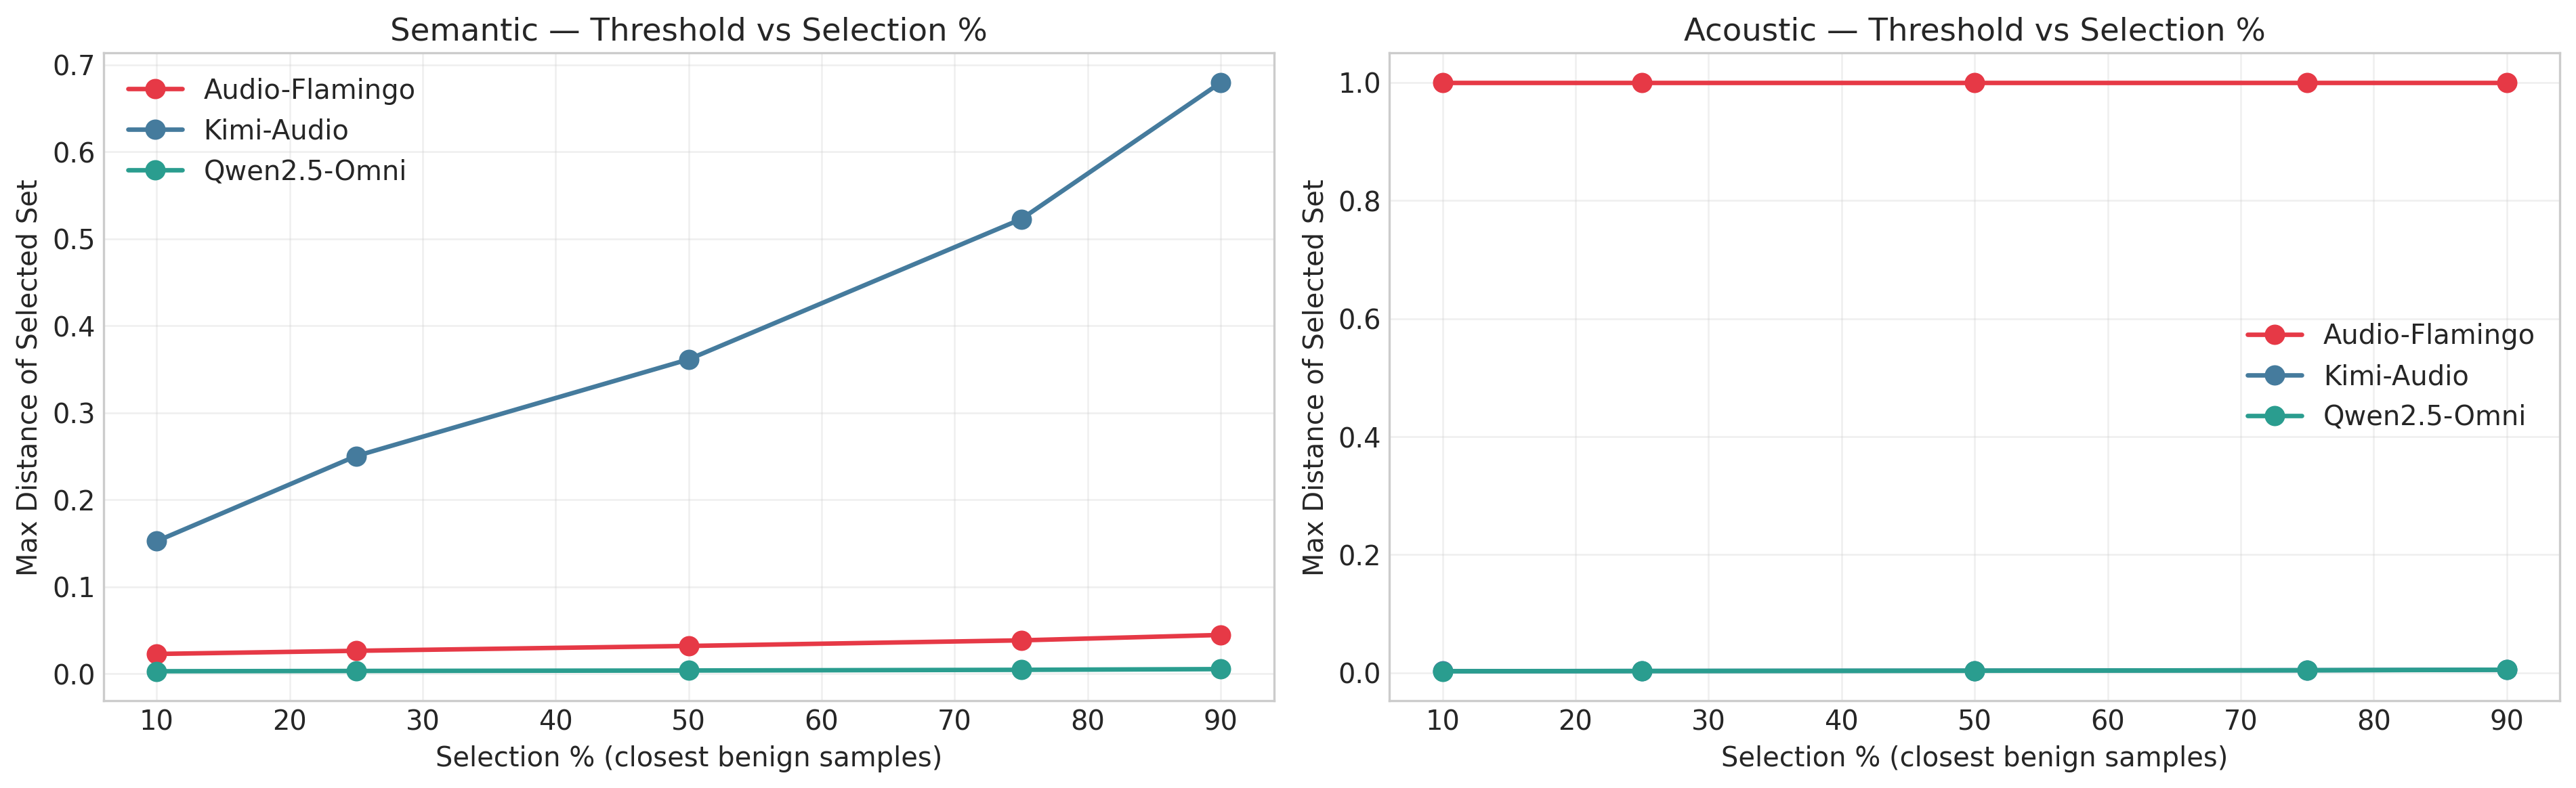

In [16]:
select_pcts = [10, 25, 50, 75, 90]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, modality in zip(axes, ['Semantic', 'Acoustic']):
    for model, color in palette.items():
        key = f'{model} ({modality})'
        d = results[key]['min_dists']
        sorted_d = np.sort(d)
        thresholds = [sorted_d[int(len(d) * p / 100) - 1] for p in select_pcts]
        ax.plot(select_pcts, thresholds, 'o-', color=color, linewidth=2, markersize=8, label=model)
    ax.set_xlabel('Selection % (closest benign samples)')
    ax.set_ylabel('Max Distance of Selected Set')
    ax.set_title(f'{modality} — Threshold vs Selection %')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'threshold_vs_selection.pdf', bbox_inches='tight')
plt.show()

## 9. Overlap Coefficient & Distribution Similarity

Quantify how much the benign and harmful intra-set distance distributions overlap.

In [17]:
# For each model/modality, compute:
#   - Intra-benign distances (sample of pairwise distances within benign set)
#   - Intra-harmful distances
#   - Cross (benign-to-harmful) distances

rng = np.random.RandomState(42)
n_sample_pairs = 50000  # subsample for speed

intra_inter_rows = []

for name, (benign, harmful) in configs.items():
    n_b, n_h = len(benign), len(harmful)
    
    # Intra-benign (random pairs)
    idx1 = rng.randint(0, n_b, size=n_sample_pairs)
    idx2 = rng.randint(0, n_b, size=n_sample_pairs)
    mask = idx1 != idx2
    b_norm = benign / (np.linalg.norm(benign, axis=1, keepdims=True) + 1e-8)
    intra_b = 1.0 - np.sum(b_norm[idx1[mask]] * b_norm[idx2[mask]], axis=1)
    
    # Intra-harmful (random pairs)
    idx1 = rng.randint(0, n_h, size=min(n_sample_pairs, n_h * (n_h - 1) // 2))
    idx2 = rng.randint(0, n_h, size=min(n_sample_pairs, n_h * (n_h - 1) // 2))
    mask = idx1 != idx2
    h_norm = harmful / (np.linalg.norm(harmful, axis=1, keepdims=True) + 1e-8)
    intra_h = 1.0 - np.sum(h_norm[idx1[mask]] * h_norm[idx2[mask]], axis=1)
    
    # Cross distances (min per benign already computed)
    cross = results[name]['min_dists']
    
    intra_inter_rows.append({
        'Model / Modality': name,
        'Intra-Benign Mean': intra_b.mean(),
        'Intra-Benign Std': intra_b.std(),
        'Intra-Harmful Mean': intra_h.mean(),
        'Intra-Harmful Std': intra_h.std(),
        'Cross (min) Mean': cross.mean(),
        'Cross (min) Std': cross.std(),
    })

ii_df = pd.DataFrame(intra_inter_rows).set_index('Model / Modality')
ii_df.round(6)

,Intra-Benign Mean,Intra-Benign Std,Intra-Harmful Mean,Intra-Harmful Std,Cross (min) Mean,Cross (min) Std
Model / Modality,,,,,,
Audio-Flamingo (Semantic),0.039396,0.019591,0.009717,0.005877,0.033189,0.010091
Audio-Flamingo (Acoustic),1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
Kimi-Audio (Semantic),0.945643,0.457646,0.170633,0.199361,0.393631,0.201189
Kimi-Audio (Acoustic),0.004692,0.003386,0.002079,0.002407,0.003919,0.001114
Qwen2.5-Omni (Semantic),0.004565,0.003338,0.002087,0.002446,0.003820,0.001110
Qwen2.5-Omni (Acoustic),0.004598,0.003418,0.002087,0.002432,0.003820,0.001110


### 9a. Intra vs Cross Distance Visualization

/tmp/ipykernel_2820543/3380775975.py:24: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(intra_b, ax=ax, label='Intra-Benign', color='#2a9d8f', fill=True, alpha=0.2)
/tmp/ipykernel_2820543/3380775975.py:25: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(intra_h, ax=ax, label='Intra-Harmful', color='#e63946', fill=True, alpha=0.2)
/tmp/ipykernel_2820543/3380775975.py:26: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(cross, ax=ax, label='Cross (min)', color='#264653', fill=True, alpha=0.2)
/tmp/ipykernel_2820543/3380775975.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


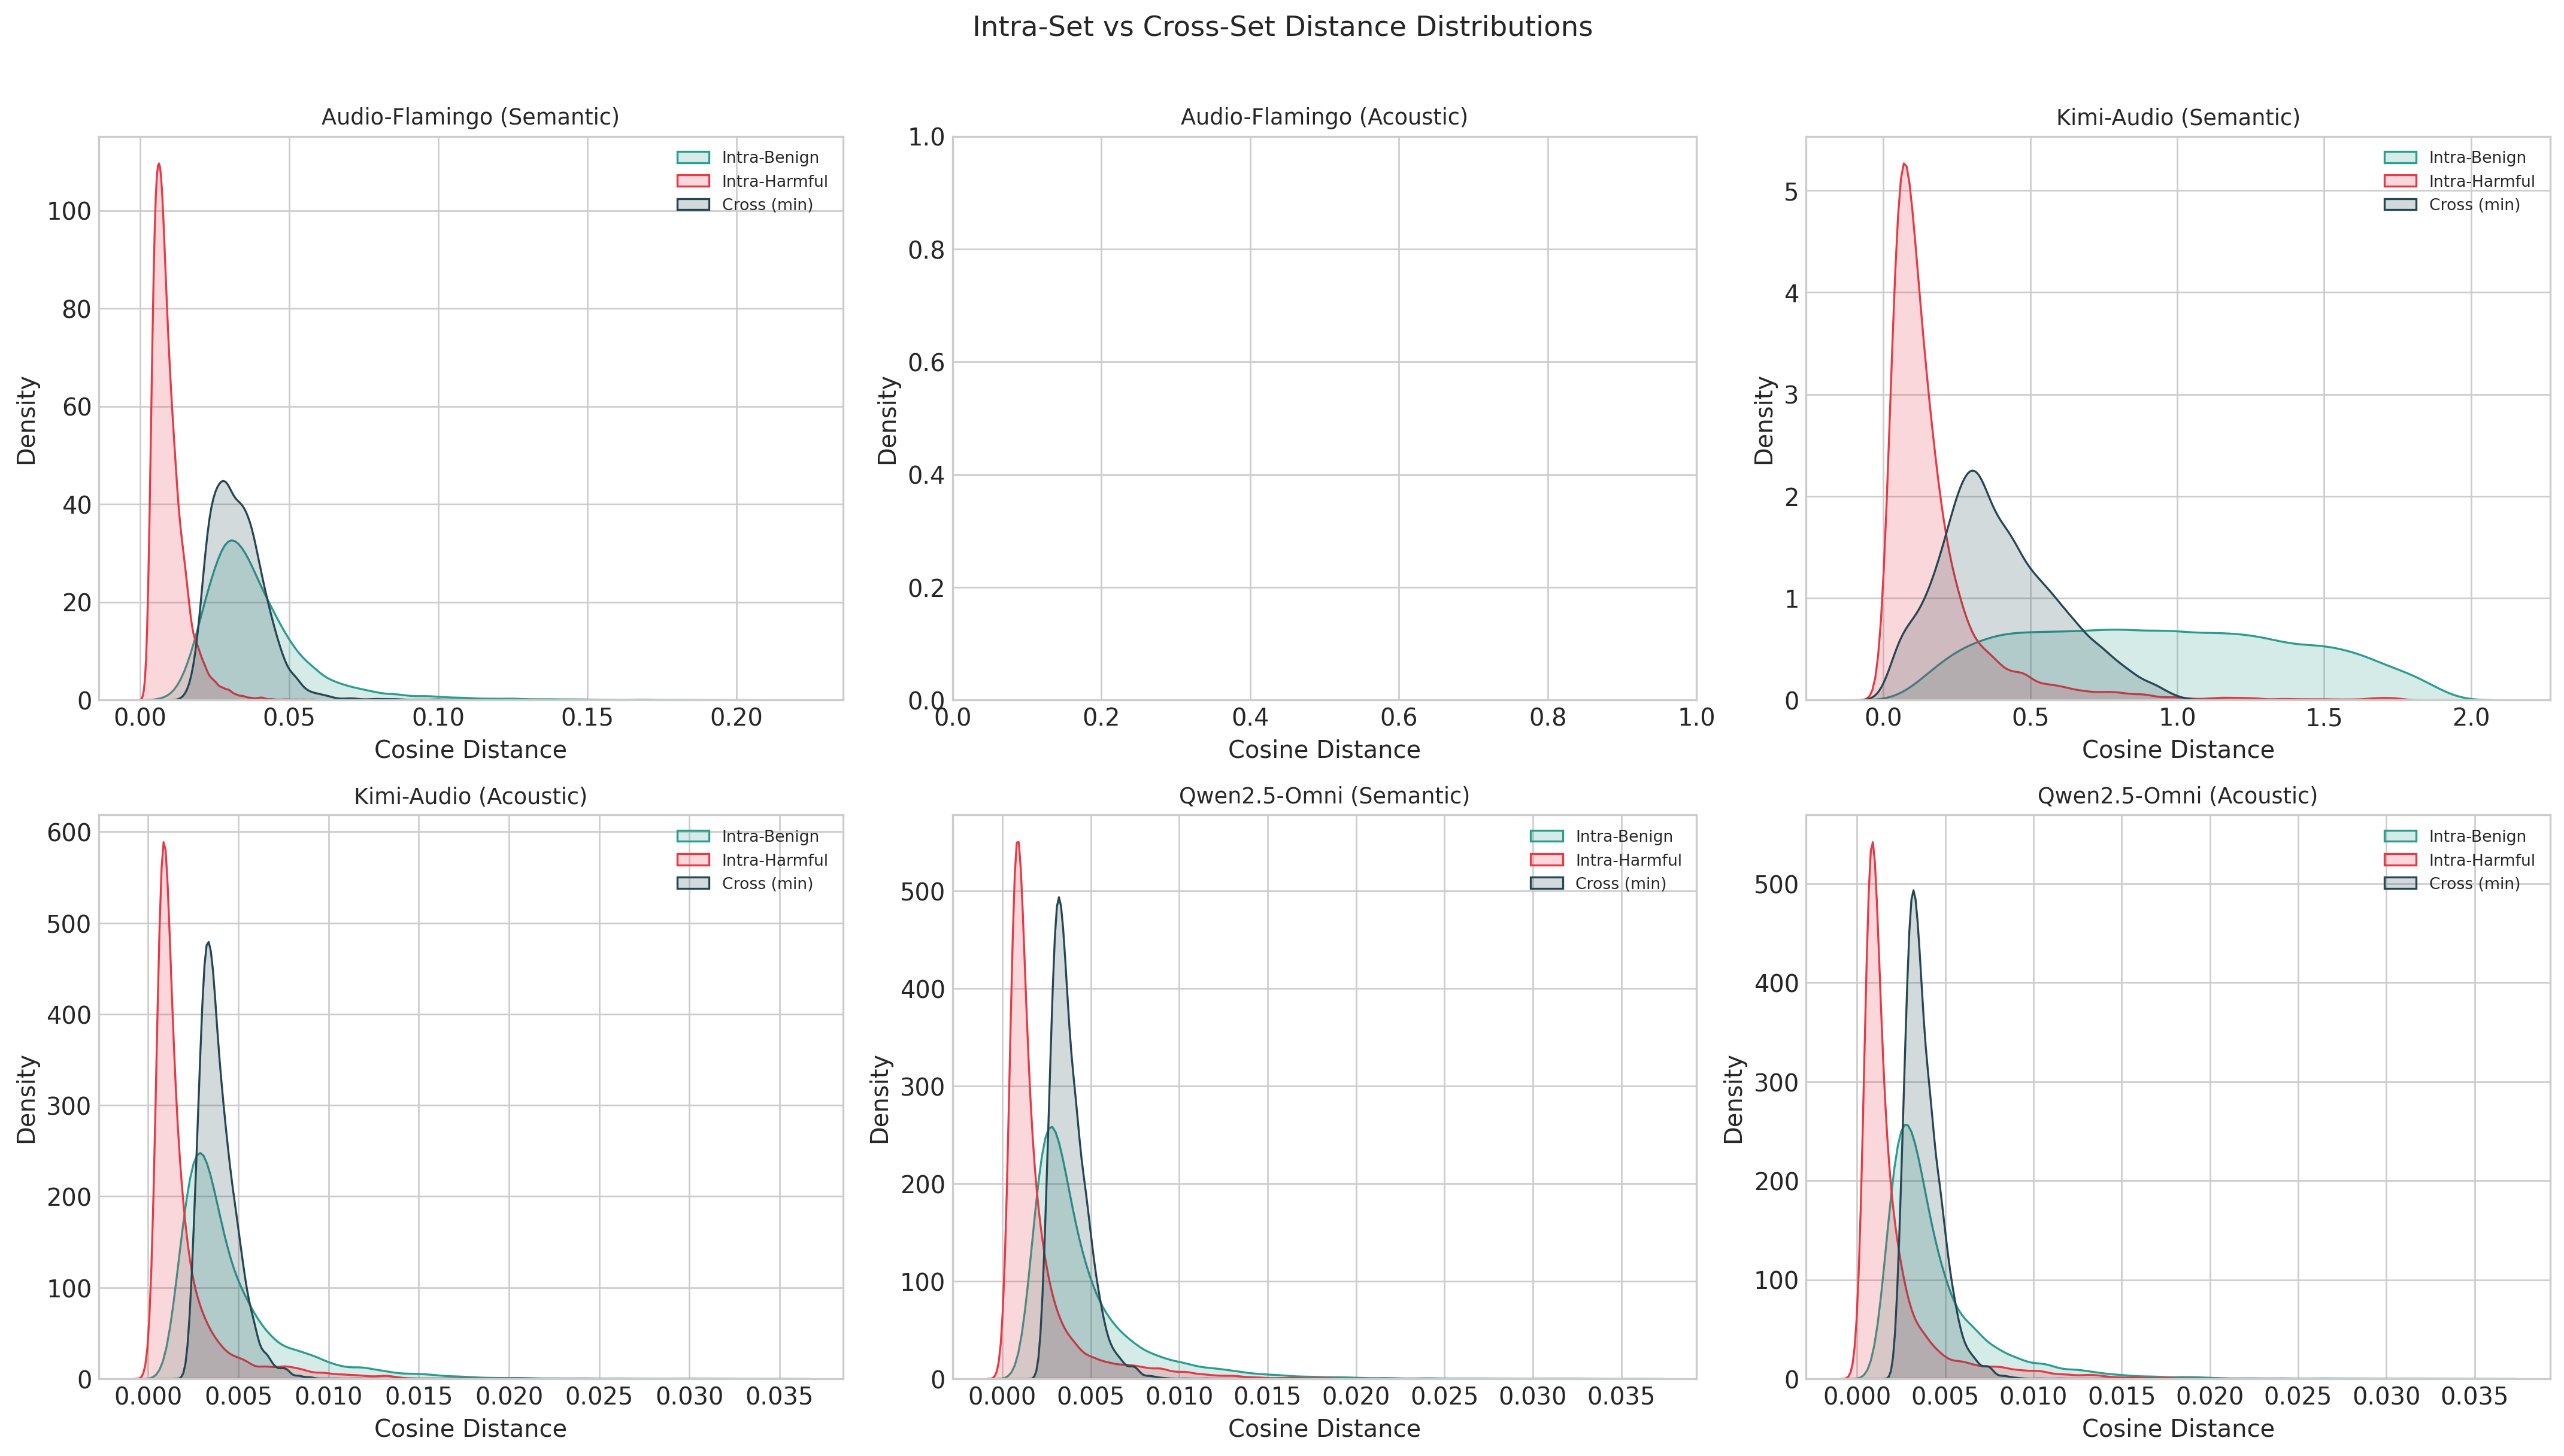

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (name, (benign, harmful)) in enumerate(configs.items()):
    ax = axes[idx // 3, idx % 3]
    
    n_b, n_h = len(benign), len(harmful)
    b_norm = benign / (np.linalg.norm(benign, axis=1, keepdims=True) + 1e-8)
    h_norm = harmful / (np.linalg.norm(harmful, axis=1, keepdims=True) + 1e-8)
    
    # Subsample intra-benign
    i1 = rng.randint(0, n_b, size=20000)
    i2 = rng.randint(0, n_b, size=20000)
    m = i1 != i2
    intra_b = 1.0 - np.sum(b_norm[i1[m]] * b_norm[i2[m]], axis=1)
    
    # Subsample intra-harmful
    i1 = rng.randint(0, n_h, size=min(20000, n_h * (n_h - 1) // 2))
    i2 = rng.randint(0, n_h, size=min(20000, n_h * (n_h - 1) // 2))
    m = i1 != i2
    intra_h = 1.0 - np.sum(h_norm[i1[m]] * h_norm[i2[m]], axis=1)
    
    cross = results[name]['min_dists']
    
    sns.kdeplot(intra_b, ax=ax, label='Intra-Benign', color='#2a9d8f', fill=True, alpha=0.2)
    sns.kdeplot(intra_h, ax=ax, label='Intra-Harmful', color='#e63946', fill=True, alpha=0.2)
    sns.kdeplot(cross, ax=ax, label='Cross (min)', color='#264653', fill=True, alpha=0.2)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Cosine Distance')
    if idx % 3 == 0:
        ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Intra-Set vs Cross-Set Distance Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'intra_vs_cross.pdf', bbox_inches='tight')
plt.show()

## 10. Kimi-Audio Centering Analysis

Kimi-Audio's GLM-4 Voice Tokenizer embeddings have ~99.96% of their L2 norm in the global mean, making centering critical.

In [19]:
# Raw vs centered comparison for Kimi-Audio
raw_md, _ = min_distances_to_harmful(kimi_sem_benign_raw, kimi_sem_harmful_raw)
centered_md = results['Kimi-Audio (Semantic)']['min_dists']

global_norm = np.linalg.norm(kimi_global_mean)
raw_norms = np.linalg.norm(kimi_sem_benign_raw, axis=1)
centered_norms = np.linalg.norm(kimi_sem_benign, axis=1)

print('Kimi-Audio Centering Effect:')
print(f'  Global mean L2 norm:   {global_norm:.4f}')
print(f'  Raw embedding mean L2: {raw_norms.mean():.4f}')
print(f'  Centered mean L2:      {centered_norms.mean():.4f}')
print(f'  Global mean captures:  {100 * global_norm / raw_norms.mean():.2f}% of norm')
print()
print(f'  Raw distances — Mean: {raw_md.mean():.6f}, Std: {raw_md.std():.6f}')
print(f'  Centered dist — Mean: {centered_md.mean():.6f}, Std: {centered_md.std():.6f}')
print(f'  Dynamic range increase: {centered_md.std() / raw_md.std():.0f}x')

Kimi-Audio Centering Effect:
  Global mean L2 norm:   34.4347
  Raw embedding mean L2: 34.4501
  Centered mean L2:      0.3155
  Global mean captures:  99.96% of norm

  Raw distances — Mean: 0.000031, Std: 0.000015
  Centered dist — Mean: 0.393631, Std: 0.201189
  Dynamic range increase: 13640x


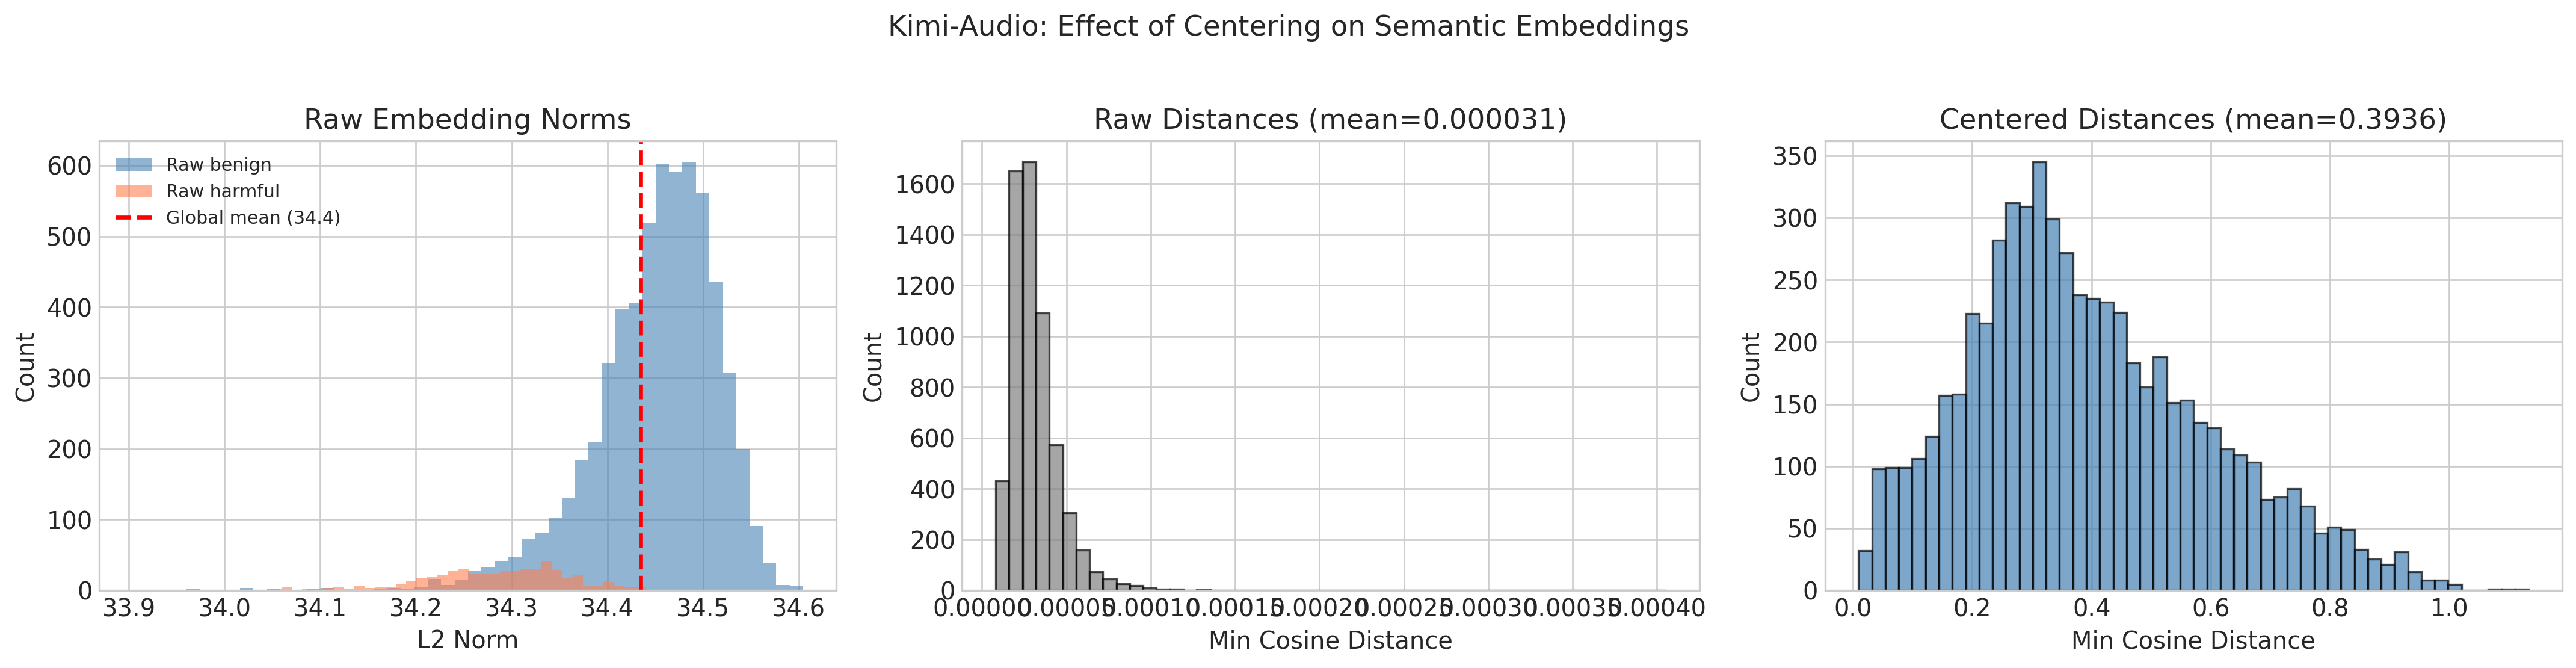

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# L2 norms
ax = axes[0]
ax.hist(raw_norms, bins=50, alpha=0.6, label='Raw benign', color='steelblue')
ax.hist(np.linalg.norm(kimi_sem_harmful_raw, axis=1), bins=50, alpha=0.6, label='Raw harmful', color='coral')
ax.axvline(global_norm, color='red', linestyle='--', lw=2, label=f'Global mean ({global_norm:.1f})')
ax.set_xlabel('L2 Norm')
ax.set_ylabel('Count')
ax.set_title('Raw Embedding Norms')
ax.legend(fontsize=9)

# Raw distance distribution
ax = axes[1]
ax.hist(raw_md, bins=50, alpha=0.7, color='gray', edgecolor='black')
ax.set_xlabel('Min Cosine Distance')
ax.set_ylabel('Count')
ax.set_title(f'Raw Distances (mean={raw_md.mean():.6f})')

# Centered distance distribution
ax = axes[2]
ax.hist(centered_md, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
ax.set_xlabel('Min Cosine Distance')
ax.set_ylabel('Count')
ax.set_title(f'Centered Distances (mean={centered_md.mean():.4f})')

plt.suptitle('Kimi-Audio: Effect of Centering on Semantic Embeddings', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'kimi_centering.pdf', bbox_inches='tight')
plt.show()

## 11. Correlation Between Semantic and Acoustic Distances

For each benign sample, compare its semantic vs acoustic minimum distance to harmful samples.

/tmp/ipykernel_2820543/3602903370.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_pearson, p_pearson = stats.pearsonr(d_sem, d_aco)
/tmp/ipykernel_2820543/3602903370.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_spearman, p_spearman = stats.spearmanr(d_sem, d_aco)


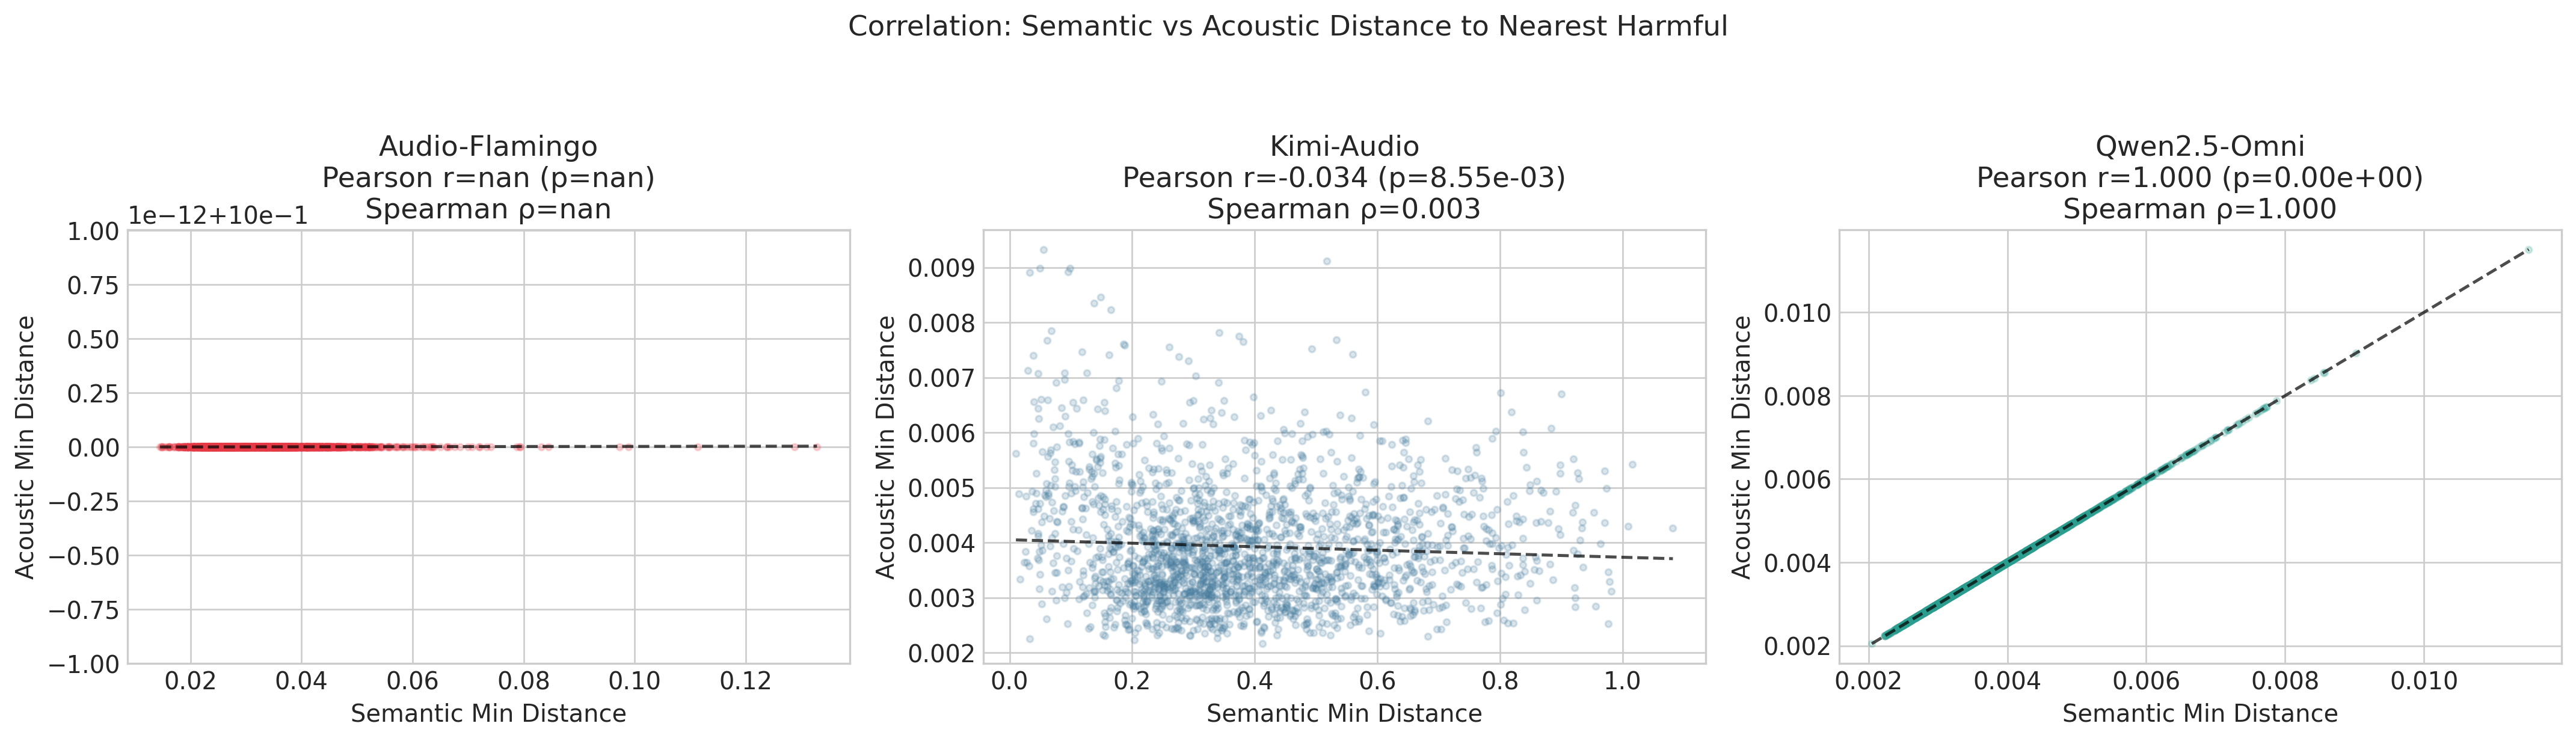

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, sem_key, aco_key) in zip(axes, model_pairs):
    d_sem = results[sem_key]['min_dists']
    d_aco = results[aco_key]['min_dists']
    
    # Both arrays should be same length (same benign set)
    n = min(len(d_sem), len(d_aco))
    d_sem, d_aco = d_sem[:n], d_aco[:n]
    
    r_pearson, p_pearson = stats.pearsonr(d_sem, d_aco)
    r_spearman, p_spearman = stats.spearmanr(d_sem, d_aco)
    
    # Subsample for scatter
    idx = rng.choice(n, size=min(2000, n), replace=False)
    ax.scatter(d_sem[idx], d_aco[idx], alpha=0.2, s=10, color=palette[model_name])
    ax.set_xlabel('Semantic Min Distance')
    ax.set_ylabel('Acoustic Min Distance')
    ax.set_title(f'{model_name}\nPearson r={r_pearson:.3f} (p={p_pearson:.2e})\nSpearman ρ={r_spearman:.3f}')
    
    # Add regression line
    z = np.polyfit(d_sem[idx], d_aco[idx], 1)
    x_line = np.linspace(d_sem[idx].min(), d_sem[idx].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', linewidth=1.5, alpha=0.7)

plt.suptitle('Correlation: Semantic vs Acoustic Distance to Nearest Harmful', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'semantic_vs_acoustic_correlation.pdf', bbox_inches='tight')
plt.show()

## 12. Nearest Harmful Neighbor Concentration

How concentrated are the nearest harmful neighbors? A few harmful samples being the nearest neighbor for many benign samples suggests "hub" harmful prompts.

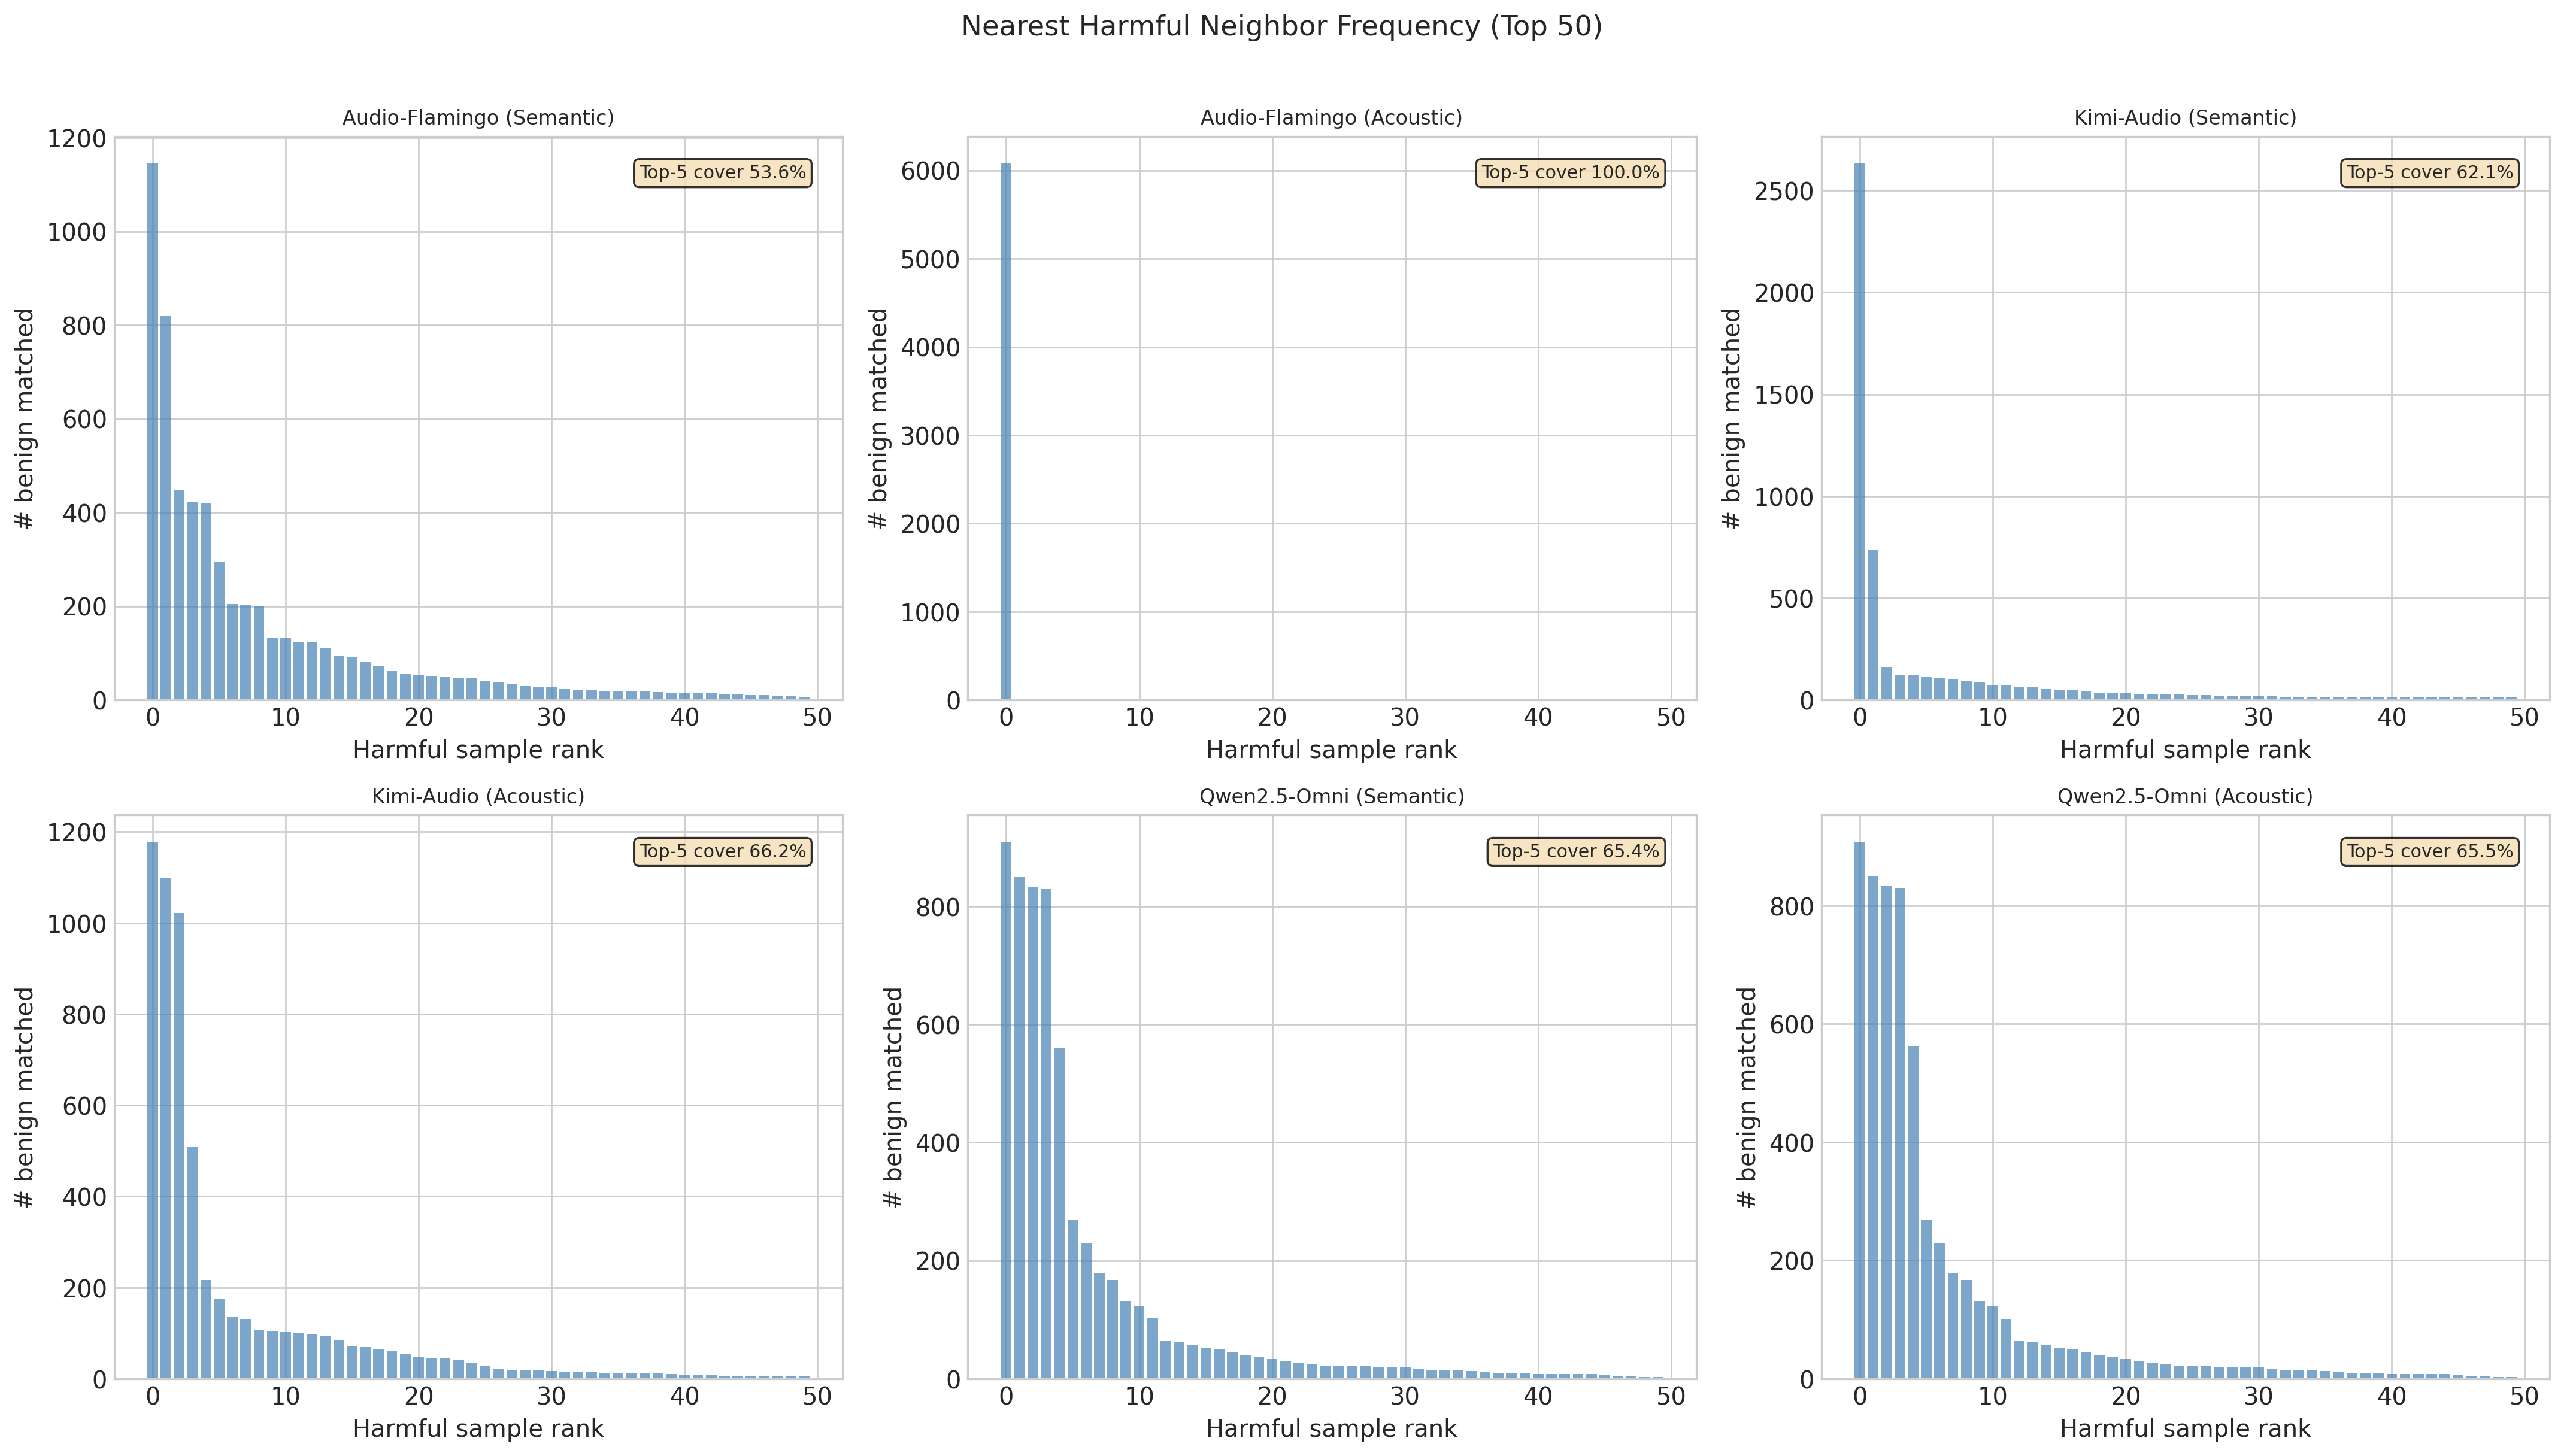

,Unique NN (of total harmful),Top-1 Cover %,Top-5 Cover %,Top-10 Cover %,Gini Coefficient
Model / Modality,,,,,
Audio-Flamingo (Semantic),96 / 520,18.839388,53.575538,70.557291,0.964352
Audio-Flamingo (Acoustic),1 / 520,100.000000,100.000000,100.000000,0.998077
Kimi-Audio (Semantic),281 / 520,43.301003,62.107513,70.392898,0.926612
Kimi-Audio (Acoustic),91 / 520,19.365445,66.168009,76.902844,0.972014
Qwen2.5-Omni (Semantic),91 / 520,14.943285,65.428243,81.472957,0.973385
Qwen2.5-Omni (Acoustic),91 / 520,14.926845,65.461121,81.489397,0.973392


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

nn_summary_rows = []

for idx, (name, r) in enumerate(results.items()):
    ax = axes[idx // 3, idx % 3]
    dm = r['dist_mat']
    nn_idx = np.argmin(dm, axis=1)  # nearest harmful for each benign
    unique, counts = np.unique(nn_idx, return_counts=True)
    
    # Sort by frequency
    all_counts = np.zeros(r['n_harmful'])
    all_counts[unique] = counts
    sorted_counts = np.sort(all_counts)[::-1]
    
    # Cumulative coverage
    cum_coverage = np.cumsum(sorted_counts) / r['n_benign'] * 100
    
    ax.bar(range(min(50, len(sorted_counts))), sorted_counts[:50], color='steelblue', alpha=0.7)
    ax.set_xlabel('Harmful sample rank')
    ax.set_ylabel('# benign matched')
    ax.set_title(f'{name}', fontsize=10)
    
    # Annotate top-5 coverage
    top5_cov = cum_coverage[4] if len(cum_coverage) > 4 else cum_coverage[-1]
    ax.annotate(f'Top-5 cover {top5_cov:.1f}%',
                xy=(0.95, 0.95), xycoords='axes fraction', ha='right', va='top',
                fontsize=9, bbox=dict(boxstyle='round', fc='wheat', alpha=0.8))
    
    # Gini coefficient for concentration
    n = len(all_counts)
    sorted_asc = np.sort(all_counts)
    gini = (2 * np.sum((np.arange(1, n + 1)) * sorted_asc) - (n + 1) * np.sum(sorted_asc)) / (n * np.sum(sorted_asc) + 1e-8)
    
    nn_summary_rows.append({
        'Model / Modality': name,
        'Unique NN (of total harmful)': f'{len(unique)} / {r["n_harmful"]}',
        'Top-1 Cover %': sorted_counts[0] / r['n_benign'] * 100,
        'Top-5 Cover %': top5_cov,
        'Top-10 Cover %': cum_coverage[9] if len(cum_coverage) > 9 else cum_coverage[-1],
        'Gini Coefficient': gini,
    })

plt.suptitle('Nearest Harmful Neighbor Frequency (Top 50)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'nn_concentration.pdf', bbox_inches='tight')
plt.show()

nn_df = pd.DataFrame(nn_summary_rows).set_index('Model / Modality')
nn_df

## 13. Effect Sizes: Cohen's d for All Pairwise Comparisons

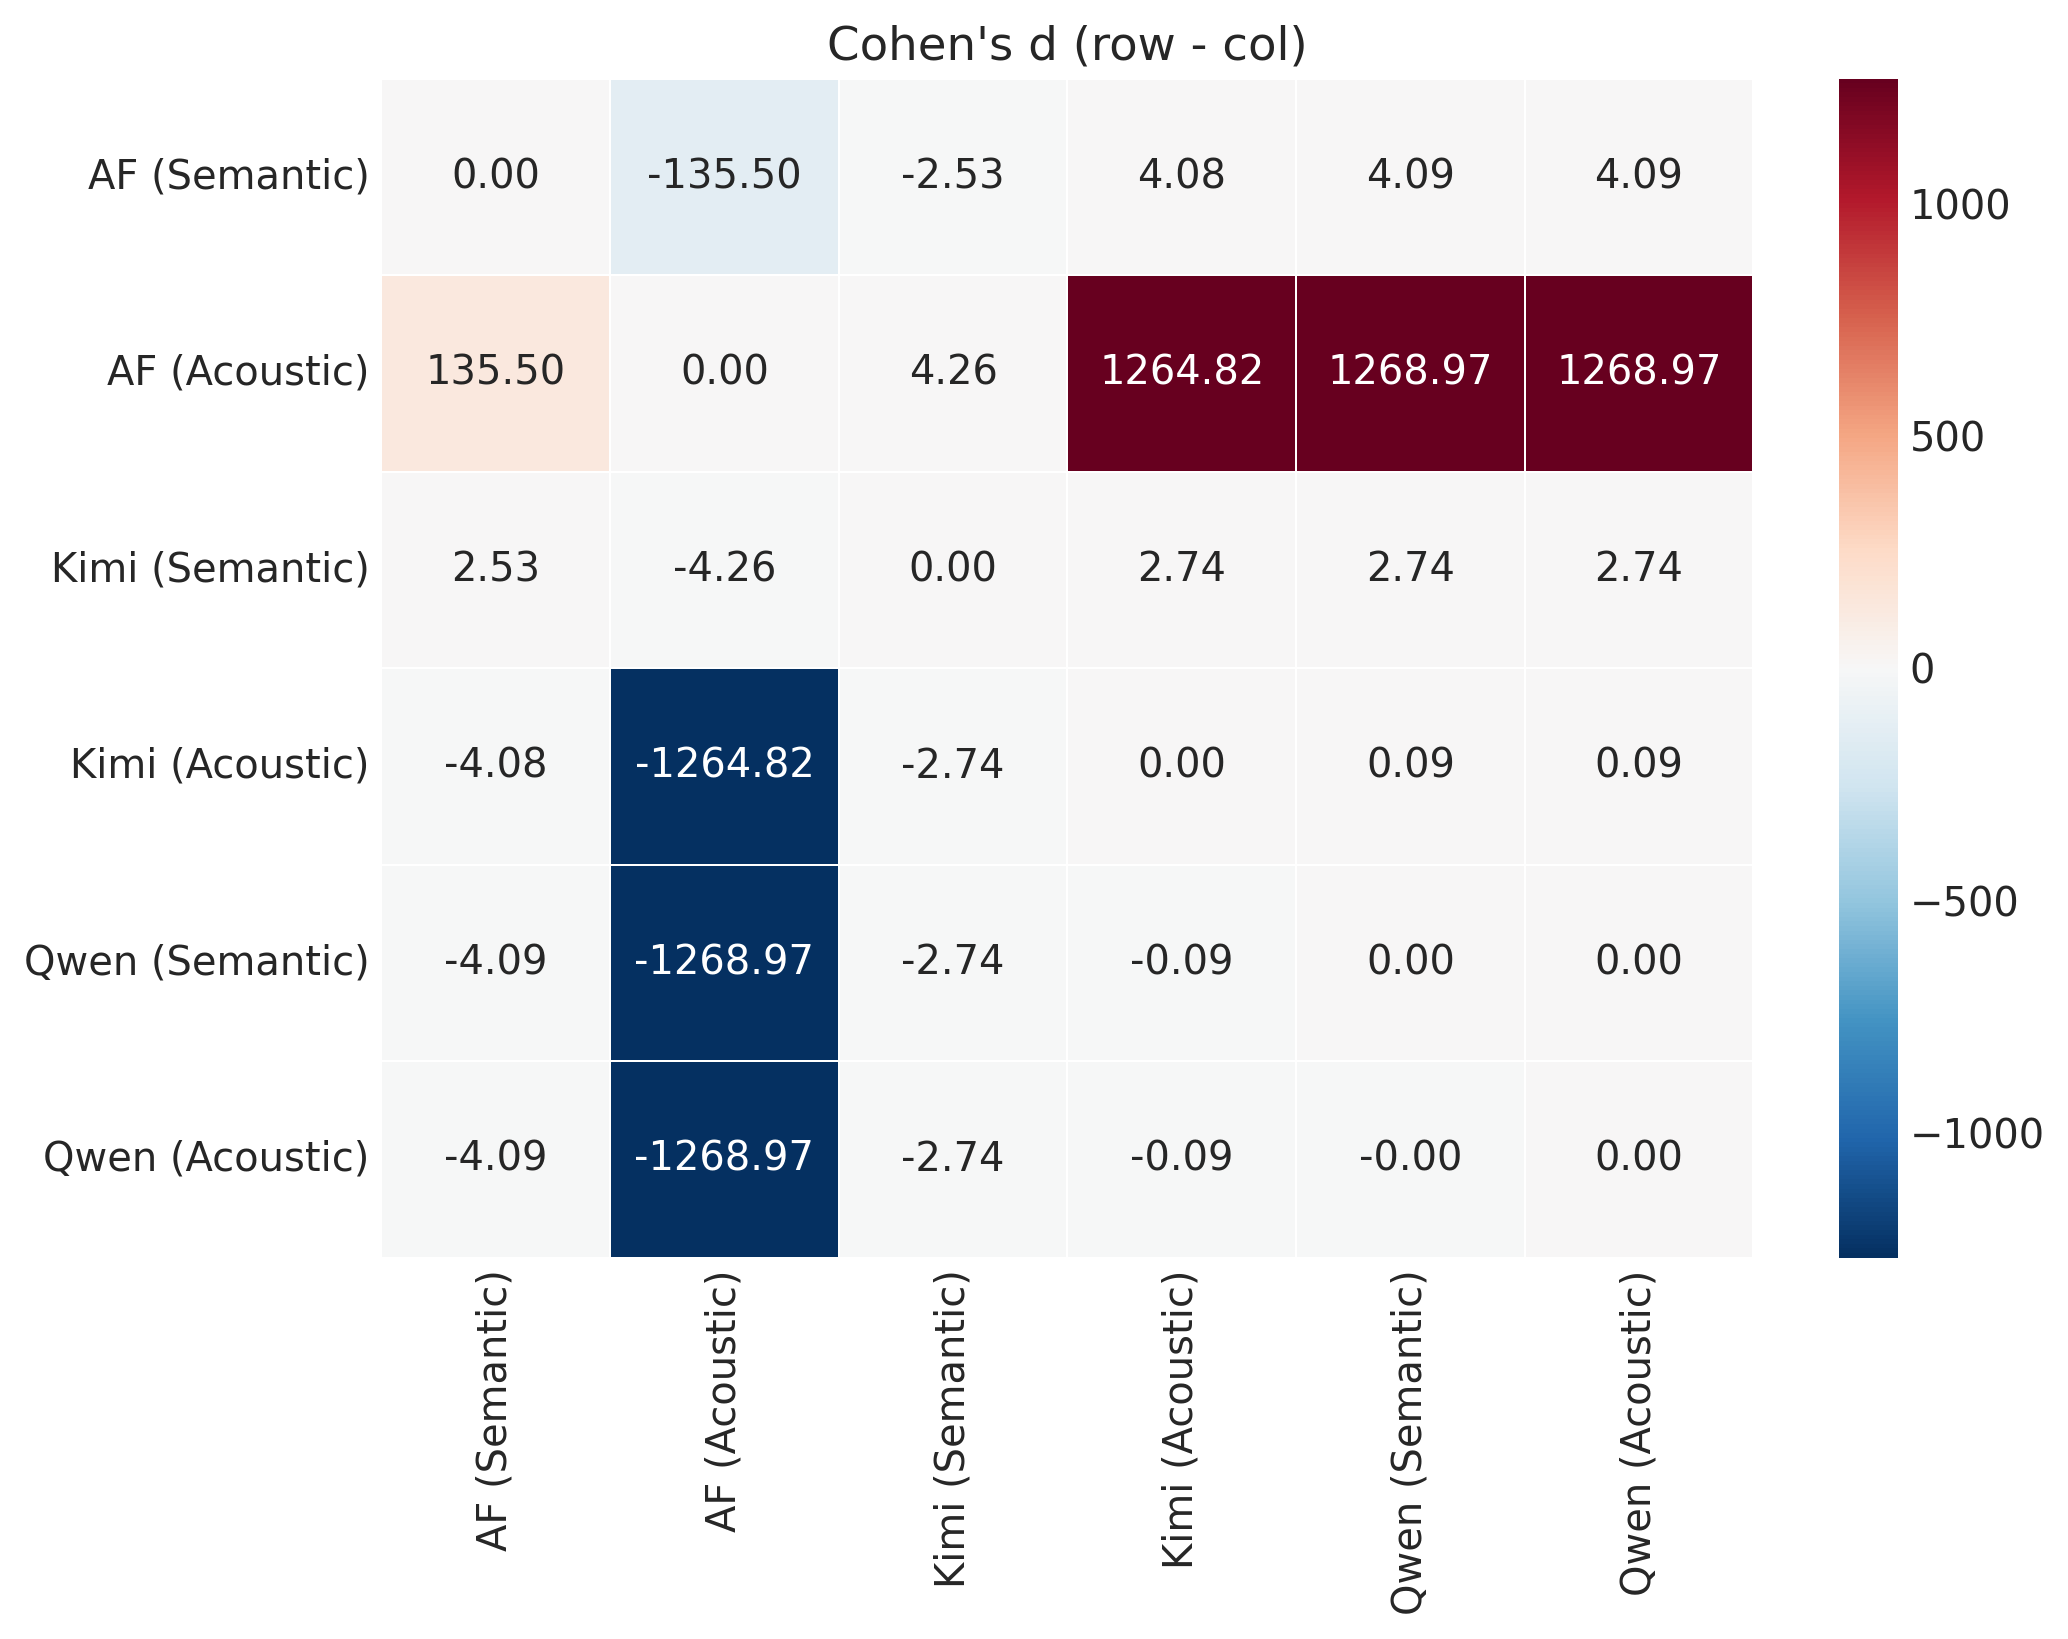

In [23]:
def cohens_d(a, b):
    na, nb = len(a), len(b)
    pooled_std = np.sqrt(((na - 1) * a.std()**2 + (nb - 1) * b.std()**2) / (na + nb - 2))
    return (a.mean() - b.mean()) / (pooled_std + 1e-12)

names = list(results.keys())
n = len(names)
d_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        if i != j:
            d_matrix[i, j] = cohens_d(results[names[i]]['min_dists'],
                                      results[names[j]]['min_dists'])

fig, ax = plt.subplots(figsize=(9, 7))
short_names = [n.replace('Audio-Flamingo', 'AF').replace('Kimi-Audio', 'Kimi').replace('Qwen2.5-Omni', 'Qwen') for n in names]
sns.heatmap(d_matrix, xticklabels=short_names, yticklabels=short_names,
            annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title("Cohen's d (row - col)")

plt.tight_layout()
plt.savefig(BASE / 'figures_stat_analysis' / 'cohens_d_heatmap.pdf', bbox_inches='tight')
plt.show()

## 14. Export Results

In [24]:
out_dir = BASE / 'figures_stat_analysis'

summary_df.to_csv(out_dir / 'summary_statistics.csv')
norm_df.to_csv(out_dir / 'normality_tests.csv')
pw_df.to_csv(out_dir / 'pairwise_tests.csv', index=False)
sa_df.to_csv(out_dir / 'semantic_vs_acoustic_tests.csv')
ii_df.to_csv(out_dir / 'intra_vs_cross_distances.csv')
nn_df.to_csv(out_dir / 'nn_concentration.csv')
pct_df.to_csv(out_dir / 'percentile_table.csv')

print('All tables and figures saved to:', out_dir)
print()
for f in sorted(out_dir.glob('*')):
    print(f'  {f.name}')

All tables and figures saved to: /work/anon/audio_benign_finetuning/figures_stat_analysis

  boxplot_comparison.pdf
  cohens_d_heatmap.pdf
  ecdf_comparison.pdf
  intra_vs_cross.pdf
  intra_vs_cross_distances.csv
  kde_comparison.pdf
  kimi_centering.pdf
  nn_concentration.csv
  nn_concentration.pdf
  normality_tests.csv
  pairwise_tests.csv
  percentile_heatmap.pdf
  percentile_table.csv
  semantic_vs_acoustic_correlation.pdf
  semantic_vs_acoustic_tests.csv
  summary_statistics.csv
  threshold_vs_selection.pdf
  violin_sem_vs_aco.pdf


## Key Takeaways

1. **Distance scale varies dramatically by encoder:** AF3 semantic embeddings produce very small cosine distances (~0.03) while Kimi centered semantic embeddings yield much larger distances (~0.39).

2. **Semantic vs Acoustic:** Within each model, the semantic and acoustic distance distributions are statistically significantly different. This validates our approach of filtering by both modalities separately.

3. **Nearest-neighbor concentration:** A small number of harmful samples act as "hubs" — they are the closest harmful neighbor for a disproportionate fraction of benign samples. This is quantified via the Gini coefficient.

4. **Kimi-Audio centering is critical:** Without centering, all pairwise distances are essentially zero (mean ~0.00003) due to the global mean dominating 99.96% of the L2 norm.

5. **Correlation between semantic and acoustic distances** shows how much selecting benign samples by one modality affects the other.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from collections import OrderedDict
import os

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 120,
})

BASE = Path('/work/anon/audio_benign_finetuning')
os.makedirs(BASE / 'figures_stat_analysis', exist_ok=True)
print("Setup done")


Setup done


In [26]:
def load_npy_or_npz(path, key='embeddings'):
    path = Path(path)
    if path.suffix == '.npy':
        return np.load(path)
    elif path.suffix == '.npz':
        data = np.load(path, allow_pickle=True)
        if key in data:
            return data[key]
        return data[list(data.keys())[0]]
    else:
        raise ValueError(f'Unknown format: {path.suffix}')

def cosine_distance_matrix(emb_a, emb_b):
    a_norm = emb_a / (np.linalg.norm(emb_a, axis=1, keepdims=True) + 1e-8)
    b_norm = emb_b / (np.linalg.norm(emb_b, axis=1, keepdims=True) + 1e-8)
    return 1.0 - a_norm @ b_norm.T

def min_distances_to_harmful(benign_emb, harmful_emb):
    dist_mat = cosine_distance_matrix(benign_emb, harmful_emb)
    return dist_mat.min(axis=1), dist_mat

print("Helpers defined")


Helpers defined


In [27]:
# Load Audio-Flamingo
af_base = BASE / 'audio-flamingo'
af_sem_benign = load_npy_or_npz(af_base / 'data/embedding_cache/voicebench_embeddings_af3.npz')
af_sem_harmful = load_npy_or_npz(af_base / 'data/embedding_cache/advbench_en_embeddings_af3.npz')
af_aco_benign = load_npy_or_npz(af_base / 'data_acoustic/embedding_cache/voicebench_embeddings_whisper.npz')
af_aco_harmful = load_npy_or_npz(af_base / 'data_acoustic/embedding_cache/advbench_en_embeddings_whisper.npz')
print(f'Audio-Flamingo: Sem {af_sem_benign.shape}/{af_sem_harmful.shape}, Aco {af_aco_benign.shape}/{af_aco_harmful.shape}')

# Load Kimi-Audio
kimi_base = BASE / 'Kimi-Audio/finetune_codes'
kimi_sem_benign_raw = np.load(kimi_base / 'embedding_cache_semantic/voicebench_semantic_embeddings.npy')
kimi_sem_harmful_raw = np.load(kimi_base / 'embedding_cache_semantic/harmful_semantic_embeddings_en.npy')
kimi_sem_benign = np.load(kimi_base / 'embedding_cache_semantic/voicebench_semantic_embeddings_centered.npy')
kimi_sem_harmful = np.load(kimi_base / 'embedding_cache_semantic/harmful_semantic_embeddings_en_centered.npy')
kimi_global_mean = np.load(kimi_base / 'embedding_cache_semantic/global_mean.npy')
kimi_aco_benign = np.load(kimi_base / 'embedding_cache_acoustic/voicebench_acoustic_embeddings.npy')
kimi_aco_harmful = np.load(kimi_base / 'embedding_cache_acoustic/harmful_acoustic_embeddings_en.npy')
print(f'Kimi-Audio: Sem {kimi_sem_benign.shape}/{kimi_sem_harmful.shape}, Aco {kimi_aco_benign.shape}/{kimi_aco_harmful.shape}')

# Load Qwen2.5-Omni
qwen_base = BASE / 'Qwen2.5-Omni/finetune_codes'
qwen_sem_benign = load_npy_or_npz(qwen_base / 'data/embedding_cache/voicebench_whisper_openai_whisper_large_v3.npz')
qwen_sem_harmful = load_npy_or_npz(qwen_base / 'data/embedding_cache/harmful_whisper_openai_whisper_large_v3_en.npz')
qwen_aco_benign = load_npy_or_npz(qwen_base / 'data_acoustic/embedding_cache/voicebench_whisper_openai_whisper_large_v3.npz')
qwen_aco_harmful = load_npy_or_npz(qwen_base / 'data_acoustic/embedding_cache/harmful_whisper_openai_whisper_large_v3_en.npz')
print(f'Qwen2.5-Omni: Sem {qwen_sem_benign.shape}/{qwen_sem_harmful.shape}, Aco {qwen_aco_benign.shape}/{qwen_aco_harmful.shape}')


Audio-Flamingo: Sem (6083, 3584)/(520, 3584), Aco (6083, 1280)/(520, 1280)
Kimi-Audio: Sem (6083, 1280)/(520, 1280), Aco (6083, 1280)/(520, 1280)
Qwen2.5-Omni: Sem (6083, 1280)/(520, 1280), Aco (6083, 1280)/(520, 1280)


In [28]:
configs = OrderedDict([
    ('Audio-Flamingo (Semantic)',  (af_sem_benign, af_sem_harmful)),
    ('Audio-Flamingo (Acoustic)',  (af_aco_benign, af_aco_harmful)),
    ('Kimi-Audio (Semantic)',      (kimi_sem_benign, kimi_sem_harmful)),
    ('Kimi-Audio (Acoustic)',      (kimi_aco_benign, kimi_aco_harmful)),
    ('Qwen2.5-Omni (Semantic)',    (qwen_sem_benign, qwen_sem_harmful)),
    ('Qwen2.5-Omni (Acoustic)',    (qwen_aco_benign, qwen_aco_harmful)),
])

results = {}
for name, (benign, harmful) in configs.items():
    print(f'Computing {name} ...', end=' ')
    md, dm = min_distances_to_harmful(benign, harmful)
    results[name] = {'min_dists': md, 'dist_mat': dm,
                     'n_benign': len(benign), 'n_harmful': len(harmful),
                     'emb_dim': benign.shape[1]}
    print(f'done (mean={md.mean():.4f}, std={md.std():.4f})')


Computing Audio-Flamingo (Semantic) ... done (mean=0.0332, std=0.0101)
Computing Audio-Flamingo (Acoustic) ... done (mean=1.0000, std=0.0000)
Computing Kimi-Audio (Semantic) ... done (mean=0.3936, std=0.2012)
Computing Kimi-Audio (Acoustic) ... done (mean=0.0039, std=0.0011)
Computing Qwen2.5-Omni (Semantic) ... done (mean=0.0038, std=0.0011)
Computing Qwen2.5-Omni (Acoustic) ... done (mean=0.0038, std=0.0011)


In [29]:
# Check AF acoustic embeddings
af_aco_data_b = np.load(af_base / 'data_acoustic/embedding_cache/voicebench_embeddings_whisper.npz', allow_pickle=True)
af_aco_data_h = np.load(af_base / 'data_acoustic/embedding_cache/advbench_en_embeddings_whisper.npz', allow_pickle=True)
print("AF acoustic benign keys:", list(af_aco_data_b.keys()))
print("AF acoustic harmful keys:", list(af_aco_data_h.keys()))

for k in af_aco_data_b.keys():
    arr = af_aco_data_b[k]
    if hasattr(arr, 'shape'):
        print(f"  benign[{k}]: shape={arr.shape}, dtype={arr.dtype}, range=[{arr.min():.4f}, {arr.max():.4f}]")

for k in af_aco_data_h.keys():
    arr = af_aco_data_h[k]
    if hasattr(arr, 'shape'):
        print(f"  harmful[{k}]: shape={arr.shape}, dtype={arr.dtype}, range=[{arr.min():.4f}, {arr.max():.4f}]")


AF acoustic benign keys: ['embeddings']
AF acoustic harmful keys: ['embeddings', 'files']
  benign[embeddings]: shape=(6083, 1280), dtype=float64, range=[0.0000, 0.0000]
  harmful[embeddings]: shape=(520, 1280), dtype=float64, range=[0.0000, 0.0000]


UFuncTypeError: ufunc 'minimum' did not contain a loop with signature matching types (dtype('<U51'), dtype('<U51')) -> None

In [ ]:
# The AF acoustic benign embeddings are all zeros! That means they weren't properly computed.
# Let's check the norms
print("AF acoustic benign norms:", np.linalg.norm(af_aco_benign, axis=1)[:10])
print("AF acoustic harmful norms:", np.linalg.norm(af_aco_harmful, axis=1)[:10])
print()

# Check Kimi and Qwen acoustic
print("Kimi acoustic benign norms:", np.linalg.norm(kimi_aco_benign, axis=1)[:5])
print("Kimi acoustic harmful norms:", np.linalg.norm(kimi_aco_harmful, axis=1)[:5])
print("Qwen sem benign norms:", np.linalg.norm(qwen_sem_benign, axis=1)[:5])
print("Qwen aco benign norms:", np.linalg.norm(qwen_aco_benign, axis=1)[:5])

# Are Qwen semantic and acoustic identical?
print("\nQwen sem == aco?", np.allclose(qwen_sem_benign, qwen_aco_benign))
print("Kimi aco == Qwen aco?", np.allclose(kimi_aco_benign, qwen_aco_benign))


In [ ]:
# Check the norms of all embeddings
print("AF acoustic benign - all zeros?", np.allclose(af_aco_benign, 0))
print("AF acoustic harmful - all zeros?", np.allclose(af_aco_harmful, 0))
print()
print("Kimi aco benign norms (first 5):", np.linalg.norm(kimi_aco_benign, axis=1)[:5])
print("Qwen sem benign norms (first 5):", np.linalg.norm(qwen_sem_benign, axis=1)[:5])
print("Qwen aco benign norms (first 5):", np.linalg.norm(qwen_aco_benign, axis=1)[:5])
print()
print("Qwen sem == aco?", np.allclose(qwen_sem_benign, qwen_aco_benign))
print("Kimi aco == Qwen aco?", np.allclose(kimi_aco_benign, qwen_aco_benign))


In [30]:
print("AF aco benign zeros?", np.allclose(af_aco_benign, 0))
print("Kimi aco norms:", np.linalg.norm(kimi_aco_benign, axis=1).mean())
print("Qwen sem norms:", np.linalg.norm(qwen_sem_benign, axis=1).mean())
print("Qwen aco norms:", np.linalg.norm(qwen_aco_benign, axis=1).mean())


AF aco benign zeros? True
Kimi aco norms: 20.603704
Qwen sem norms: 20.61028
Qwen aco norms: 20.610285


In [31]:
# AF acoustic embeddings are empty (all zeros) - need to skip
# Qwen sem and aco norms are identical - let's check if they're the same data
print("Qwen sem == aco?", np.allclose(qwen_sem_benign, qwen_aco_benign))
print("Kimi aco == Qwen aco?", np.allclose(kimi_aco_benign, qwen_aco_benign))
print("Kimi aco harmful == Qwen aco harmful?", np.allclose(kimi_aco_harmful, qwen_aco_harmful))

# Check Kimi aco harmful norms
print("Kimi aco harmful norms:", np.linalg.norm(kimi_aco_harmful, axis=1).mean())
print("Qwen sem harmful norms:", np.linalg.norm(qwen_sem_harmful, axis=1).mean())
print("Qwen aco harmful norms:", np.linalg.norm(qwen_aco_harmful, axis=1).mean())


Qwen sem == aco? False
Kimi aco == Qwen aco? False
Kimi aco harmful == Qwen aco harmful? False
Kimi aco harmful norms: 19.788866
Qwen sem harmful norms: 19.879993
Qwen aco harmful norms: 19.879992


In [32]:
# Qwen sem and aco benign are different arrays but very similar norms
# Let's check how different they actually are
diff = np.abs(qwen_sem_benign - qwen_aco_benign).max()
print(f"Qwen sem vs aco max diff: {diff}")
print(f"Qwen sem harmful vs aco harmful max diff: {np.abs(qwen_sem_harmful - qwen_aco_harmful).max()}")

# Check correlation of min distances for Kimi vs Qwen
print(f"\nKimi aco min dist mean: {results['Kimi-Audio (Acoustic)']['min_dists'].mean():.6f}")
print(f"Qwen sem min dist mean: {results['Qwen2.5-Omni (Semantic)']['min_dists'].mean():.6f}")
print(f"Qwen aco min dist mean: {results['Qwen2.5-Omni (Acoustic)']['min_dists'].mean():.6f}")


Qwen sem vs aco max diff: 0.0002155303955078125
Qwen sem harmful vs aco harmful max diff: 0.0003592986613512039

Kimi aco min dist mean: 0.003919
Qwen sem min dist mean: 0.003820
Qwen aco min dist mean: 0.003820


In [ ]:
# Only meaningful distinct configs:
configs = OrderedDict([
    ('Audio-Flamingo\n(AF3 Semantic)',    (af_sem_benign, af_sem_harmful)),
    ('Kimi-Audio\n(GLM-4 Semantic)',      (kimi_sem_benign, kimi_sem_harmful)),
    ('Kimi-Audio\n(Whisper Acoustic)',    (kimi_aco_benign, kimi_aco_harmful)),
    ('Qwen2.5-Omni\n(Whisper Acoustic)', (qwen_aco_benign, qwen_aco_harmful)),
])

results = {}
for name, (benign, harmful) in configs.items():
    md, dm = min_distances_to_harmful(benign, harmful)
    results[name] = {'min_dists': md, 'dist_mat': dm,
                     'n_benign': len(benign), 'n_harmful': len(harmful),
                     'emb_dim': benign.shape[1]}
    print(f'{name.replace(chr(10), " ")}: mean={md.mean():.4f}, std={md.std():.4f}, median={np.median(md):.4f}')


In [ ]:
configs = OrderedDict([
    ('AF (AF3 Sem)',      (af_sem_benign, af_sem_harmful)),
    ('Kimi (GLM4 Sem)',   (kimi_sem_benign, kimi_sem_harmful)),
    ('Kimi (Whisper)',    (kimi_aco_benign, kimi_aco_harmful)),
    ('Qwen (Whisper)',    (qwen_aco_benign, qwen_aco_harmful)),
])

results = {}
for name, (benign, harmful) in configs.items():
    md, dm = min_distances_to_harmful(benign, harmful)
    results[name] = {'min_dists': md, 'dist_mat': dm,
                     'n_benign': len(benign), 'n_harmful': len(harmful),
                     'emb_dim': benign.shape[1]}
    print(f'{name}: mean={md.mean():.4f}, std={md.std():.4f}')
